GÖRÜNTÜYE CANNY UYGULA KAYDET 

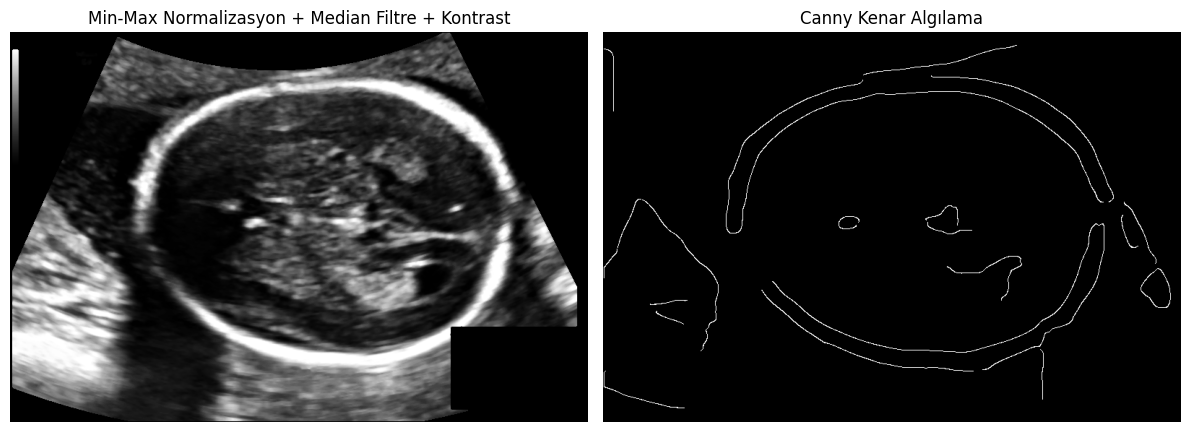

Canny sonucu başarıyla kaydedildi: C:\Users\firyat\OneDrive\Desktop\canny_result.png


In [113]:
import matplotlib.pyplot as plt
from skimage import io, filters, exposure, feature, color
import numpy as np

# Test görüntüsü dosya yolu
image_path = r"../data/test_images/3.png"  # Test görüntüsünün yolu

# Görüntüyü yükle ve gri tonlamaya çevir
image = io.imread(image_path)

# Dört kanallıysa (örneğin RGBA), alfa kanalını kaldır
if image.ndim == 3 and image.shape[2] == 4:
    image = image[:, :, :3]  # İlk üç kanalı (RGB) alın

# RGB ise gri tonlamaya çevir
if image.ndim == 3:
    image = color.rgb2gray(image)

# 1. Min-Max normalizasyonu
def min_max_normalize(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image))

normalized_image = min_max_normalize(image)

# 2. Median filtresi ile gürültü giderme
filtered_image = filters.median(normalized_image)

# 3. Kontrast artırma
contrast_image = exposure.adjust_gamma(filtered_image, gamma=1.2)  # Gamma değeri ile kontrast artırma

# 4. Canny kenar algılama
edges = feature.canny(contrast_image, sigma=8)  # Sigma kenar algılama hassasiyeti

# Görüntüleri görselleştirme
plt.figure(figsize=(12, 8))

# Median filtre + Kontrast
plt.subplot(1, 2, 1)
plt.imshow(contrast_image, cmap='gray')
plt.title("Min-Max Normalizasyon + Median Filtre + Kontrast")
plt.axis('off')

# Canny Kenar Algılama
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Kenar Algılama")
plt.axis('off')

plt.tight_layout()
plt.show()

# Canny sonucunu kaydetme fonksiyonu
def save_canny_result(image, file_path):
   
    plt.imsave(file_path, image, cmap='gray')

# Dosya yolu
canny_save_path = r"../results/canny_result.png"

# Canny sonucunu kaydet
save_canny_result(edges, canny_save_path)

print(f"Canny sonucu başarıyla kaydedildi: {canny_save_path}")


 KENAR ÜZERİNDE ÇİZGİ ÇİZİMİ

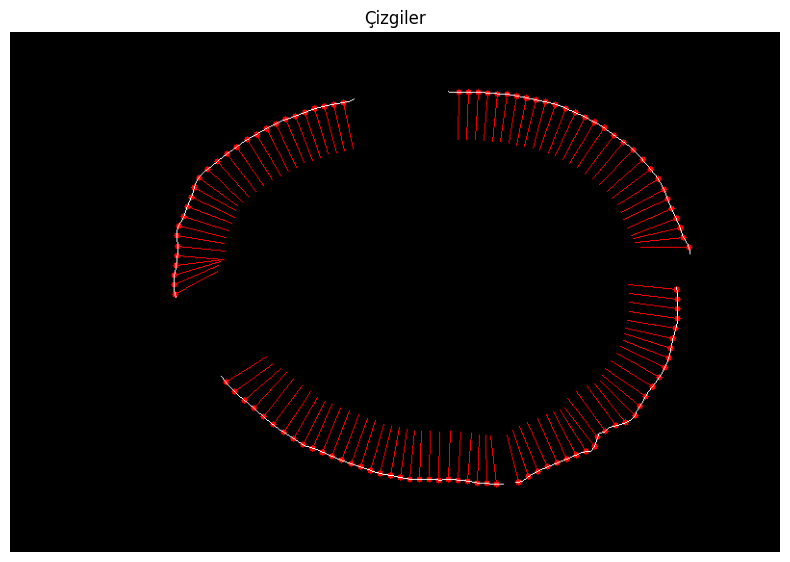

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def draw_equidistant_lines(skeleton_image, line_length=40, step=10, thickness=1):
    h, w = skeleton_image.shape
    
    # Skeleton üzerindeki noktaları bul
    y_coords, x_coords = np.where(skeleton_image > 0)
    points = np.column_stack((y_coords, x_coords))
    
    # Kontur noktalarını sırala
    ordered_points = []
    current_point = points[0]
    remaining_points = list(points)
    remaining_points.pop(0)
    
    while remaining_points:
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        next_idx = np.argmin(distances)
        current_point = remaining_points[next_idx]
        ordered_points.append(current_point)
        remaining_points.pop(next_idx)
    
    ordered_points = np.array(ordered_points)
    lines_image = np.zeros_like(skeleton_image, dtype=np.uint8)
    window_size = 40
    
    # Eşit aralıklı indeksleri hesapla
    indices = np.linspace(0, len(ordered_points)-1, len(ordered_points)//step, dtype=int)
    
    for i in indices:
        if i >= 2 and i < len(ordered_points) - 2:
            # Mevcut nokta
            y, x = ordered_points[i]
            
            # Yerel eğri yönünü hesapla
            points_before = ordered_points[max(0, i-window_size):i]
            points_after = ordered_points[i:min(i+window_size, len(ordered_points))]

            # Ortalama yön vektörünü hesapla
            dy = np.mean(points_after[:, 0]) - np.mean(points_before[:, 0])
            dx = np.mean(points_after[:, 1]) - np.mean(points_before[:, 1])
            
            # Teğet vektörünü normalize et
            magnitude = np.sqrt(dx*dx + dy*dy)
            if magnitude > 0:
                dx = dx / magnitude
                dy = dy / magnitude
                
                # Çizginin başlangıç noktasına dik vektörü hesapla (normal vektör)
                # Dik doğrultudaki iki alternatif vektör
                nx1, ny1 = -dy, dx  # 90 derece dönüş
                nx2, ny2 = dy, -dx  # Diğer 90 derece dönüş
                
                # Çizginin başlangıç noktası skeleton üzerinde
                x_start = int(x)
                y_start = int(y)
                
                # Çizginin bitiş noktası (dik doğrultuda olan vektörlerden birini kullan)
                x_end = int(x + nx1 * line_length)  # Normal vektörü ile dik çizgi
                y_end = int(y + ny1 * line_length)  # Normal vektörü ile dik çizgi
                
                # Görüntü sınırlarını kontrol et
                if (0 <= y_end < h and 0 <= x_end < w):
                    # Çizgiyi çiz
                    cv2.line(lines_image, 
                            (x_start, y_start),
                            (x_end, y_end),
                            255, 
                            thickness)
                    
                    # Başlangıç noktasını belirginleştir (kırmızı bir daire ekle)
                    cv2.circle(lines_image, (x_start, y_start), 3, 255, -1)  # Küçük bir daire
    
    return lines_image

def apply_skeleton(binary_path):
    # Binary görüntüyü oku
    img = cv2.imread(binary_path, 0)
    
    # Binary görüntü oluştur
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # Skeletonization uygula
    skeleton = skeletonize(binary > 0)
    skeleton_image = skeleton.astype(np.uint8) * 255
    
    # Çizgileri çiz
    lines_image = draw_equidistant_lines(
        skeleton_image, 
        line_length=50, 
        step=10,
        thickness=1
    )
    
    # Skeleton ve çizgileri RGB'ye dönüştür
    skeleton_rgb = cv2.cvtColor(skeleton_image, cv2.COLOR_GRAY2RGB)
    lines_colored = np.zeros_like(skeleton_rgb)
    lines_colored[lines_image > 0] = [255, 0, 0]  # Çizgileri kırmızı yap
    
    # Skeleton üzerine çizgileri ekle
    skeleton_with_lines = cv2.addWeighted(skeleton_rgb, 1, lines_colored, 1, 0)
    
    # Sadece skeleton + çizgileri göster
    plt.figure(figsize=(8, 8))
    plt.imshow(skeleton_with_lines)
    plt.title('Çizgiler')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return skeleton_image, lines_image, skeleton_with_lines

# Kullanım
binary_path = r"../results/kenar1.png"

skeleton_result, lines_result, skeleton_with_lines = apply_skeleton(binary_path)


 ÇİZGİLERİ ORJİNALDE GÖSTER

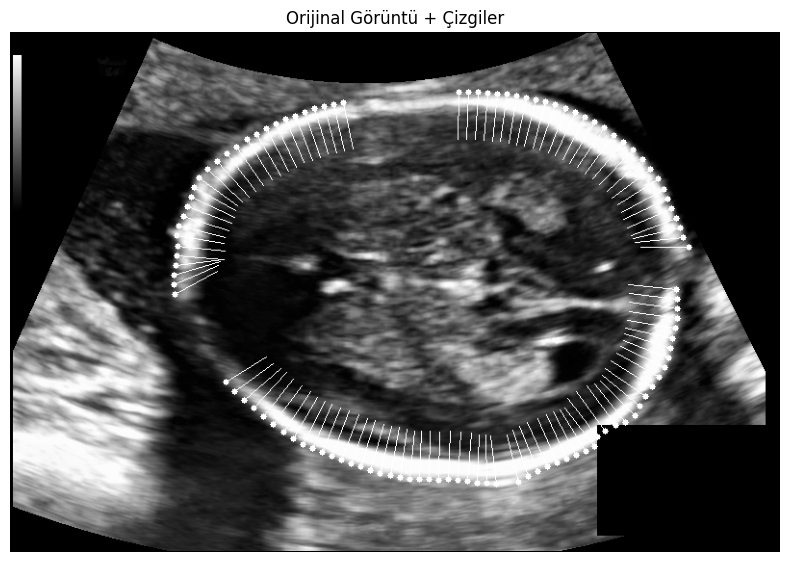

In [115]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def draw_equidistant_lines(skeleton_image, line_length=40, step=10, thickness=1):
    h, w = skeleton_image.shape
    
    # Skeleton üzerindeki noktaları bul
    y_coords, x_coords = np.where(skeleton_image > 0)
    points = np.column_stack((y_coords, x_coords))
    
    # Kontur noktalarını sırala
    ordered_points = []
    current_point = points[0]
    remaining_points = list(points)
    remaining_points.pop(0)
    
    while remaining_points:
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        next_idx = np.argmin(distances)
        current_point = remaining_points[next_idx]
        ordered_points.append(current_point)
        remaining_points.pop(next_idx)
    
    ordered_points = np.array(ordered_points)
    lines_image = np.zeros_like(skeleton_image, dtype=np.uint8)
    window_size = 40
    
    # Eşit aralıklı indeksleri hesapla
    indices = np.linspace(0, len(ordered_points)-1, len(ordered_points)//step, dtype=int)
    
    for i in indices:
        if i >= 2 and i < len(ordered_points) - 2:
            # Mevcut nokta
            y, x = ordered_points[i]
            
            # Yerel eğri yönünü hesapla
            points_before = ordered_points[max(0, i-window_size):i]
            points_after = ordered_points[i:min(i+window_size, len(ordered_points))]

            # Ortalama yön vektörünü hesapla
            dy = np.mean(points_after[:, 0]) - np.mean(points_before[:, 0])
            dx = np.mean(points_after[:, 1]) - np.mean(points_before[:, 1])
            
            # Teğet vektörünü normalize et
            magnitude = np.sqrt(dx*dx + dy*dy)
            if magnitude > 0:
                dx = dx / magnitude
                dy = dy / magnitude
                
                # Çizginin başlangıç noktasına dik vektörü hesapla (normal vektör)
                # Dik doğrultudaki iki alternatif vektör
                nx1, ny1 = -dy, dx  # 90 derece dönüş
                nx2, ny2 = dy, -dx  # Diğer 90 derece dönüş
                
                # Çizginin başlangıç noktası skeleton üzerinde
                x_start = int(x)
                y_start = int(y)
                
                # Çizginin bitiş noktası (dik doğrultuda olan vektörlerden birini kullan)
                x_end = int(x + nx1 * line_length)  # Normal vektörü ile dik çizgi
                y_end = int(y + ny1 * line_length)  # Normal vektörü ile dik çizgi
                
                # Görüntü sınırlarını kontrol et
                if (0 <= y_end < h and 0 <= x_end < w):
                    # Çizgiyi çiz
                    cv2.line(lines_image, 
                            (x_start, y_start),
                            (x_end, y_end),
                            255, 
                            thickness)
                    
                    # Başlangıç noktasını belirginleştir (kırmızı bir daire ekle)
                    cv2.circle(lines_image, (x_start, y_start), 3, 255, -1)  # Küçük bir daire
    
    return lines_image

def apply_skeleton(binary_path, original_image_path):
    # Binary görüntüyü oku
    img = cv2.imread(binary_path, 0)
    
    # Binary görüntü oluştur
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    
    # Skeletonization uygula
    skeleton = skeletonize(binary > 0)
    skeleton_image = skeleton.astype(np.uint8) * 255
    
    # Çizgileri çiz
    lines_image = draw_equidistant_lines(
        skeleton_image, 
        line_length=50, 
        step=10,
        thickness=1
    )
    
    # Orijinal siyah-beyaz görüntüyü oku
    original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
    
    # Çizgileri orijinal görüntüye ekle
    lines_colored = np.zeros_like(original_image)
    lines_colored[lines_image > 0] = 255  # Çizgileri beyaz yap
    
    # Orijinal görüntü üzerine çizgileri ekle
    final_image = cv2.addWeighted(original_image, 1, lines_colored, 1, 0)
    
    # Orijinal siyah-beyaz görüntü üzerine çizgileri göster
    plt.figure(figsize=(8, 8))
    plt.imshow(final_image, cmap='gray')
    plt.title('Orijinal Görüntü + Çizgiler')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return skeleton_image, lines_image, final_image

# Kullanım
binary_path = r"../results/kenar1.png"
original_image_path = r"../data/test_images/3.png"

skeleton_result, lines_result, final_result = apply_skeleton(binary_path, original_image_path)


ÇİZGİLERİN RENK DEĞERLERİNDEN OLUŞAN VEKTÖRLERİ OLUŞTUR

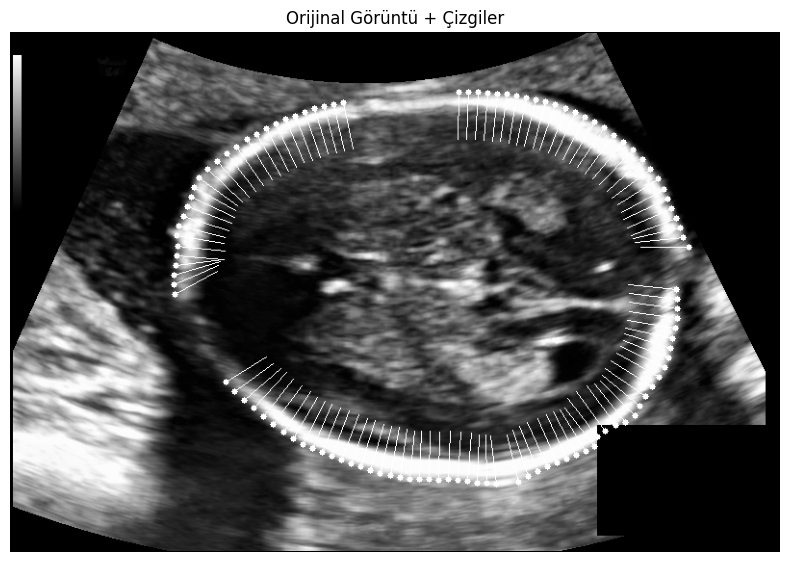


Toplam vektör sayısı: 113
Vektör boyutları: (113, 50)

İlk 3 vektörün örnek değerleri:

Vektör 1:
[106 129 143 159 175 190 213 233 244 250 251 250 241 227 206 179 159 153
 149 142 133 104  83  81  89  88  83  83  84  74  61  52  52  55  55  54
  54  55  48  38  33  31  35  39  44  46  50  50  46  46]

Vektör 2:
[128 152 158 149 148 170 206 226 241 251 251 241 228 209 188 161 145 142
 148 142 116  83  63  52  51  51  52  52  65  67  60  50  44  42  44  46
  50  49  39  34  39  52  60  63  63  62  61  55  46  42]

Vektör 3:
[106 122 148 163 170 200 216 233 249 252 252 252 250 229 198 158 142 138
 122  98  85  77  74  75  81  85  79  68  65  64  54  46  42  40  37  29
  31  35  30  30  39  49  51  50  46  44  40  39  37  33]


In [116]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def draw_equidistant_lines(skeleton_image, original_image, line_length=40, step=10, thickness=1):
    h, w = skeleton_image.shape
    
    # Skeleton üzerindeki noktaları bul
    y_coords, x_coords = np.where(skeleton_image > 0)
    points = np.column_stack((y_coords, x_coords))
    
    # Kontur noktalarını sırala
    ordered_points = []
    current_point = points[0]
    remaining_points = list(points)
    remaining_points.pop(0)
    
    while remaining_points:
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        next_idx = np.argmin(distances)
        current_point = remaining_points[next_idx]
        ordered_points.append(current_point)
        remaining_points.pop(next_idx)
    
    ordered_points = np.array(ordered_points)
    lines_image = np.zeros_like(skeleton_image, dtype=np.uint8)
    window_size = 40
    
    # Renk vektörlerini saklamak için liste
    color_vectors = []
    
    # Eşit aralıklı indeksleri hesapla
    indices = np.linspace(0, len(ordered_points)-1, len(ordered_points)//step, dtype=int)
    
    for i in indices:
        if i >= 2 and i < len(ordered_points) - 2:
            y, x = ordered_points[i]
            
            points_before = ordered_points[max(0, i-window_size):i]
            points_after = ordered_points[i:min(i+window_size, len(ordered_points))]

            dy = np.mean(points_after[:, 0]) - np.mean(points_before[:, 0])
            dx = np.mean(points_after[:, 1]) - np.mean(points_before[:, 1])
            
            magnitude = np.sqrt(dx*dx + dy*dy)
            if magnitude > 0:
                dx = dx / magnitude
                dy = dy / magnitude
                
                nx1, ny1 = -dy, dx
                
                x_start = int(x)
                y_start = int(y)
                x_end = int(x + nx1 * line_length)
                y_end = int(y + ny1 * line_length)
                
                if (0 <= y_end < h and 0 <= x_end < w):
                    # Çizgiyi çiz
                    cv2.line(lines_image, 
                            (x_start, y_start),
                            (x_end, y_end),
                            255, 
                            thickness)
                    
                    # Çizgi boyunca renk değerlerini topla
                    color_vector = []
                    num_samples = 50  # Örnekleme sayısı
                    for t in np.linspace(0, 1, num_samples):
                        sample_x = int(x_start + t * (x_end - x_start))
                        sample_y = int(y_start + t * (y_end - y_start))
                        if 0 <= sample_y < h and 0 <= sample_x < w:
                            color_vector.append(original_image[sample_y, sample_x])
                    
                    color_vectors.append(np.array(color_vector))
                    
                    cv2.circle(lines_image, (x_start, y_start), 3, 255, -1)
    
    return lines_image, np.array(color_vectors)

def apply_skeleton(binary_path, original_image_path):
    img = cv2.imread(binary_path, 0)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary > 0)
    skeleton_image = skeleton.astype(np.uint8) * 255
    
    # Orijinal görüntüyü oku
    original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
    
    # Çizgileri çiz ve renk vektörlerini al
    lines_image, color_vectors = draw_equidistant_lines(
        skeleton_image,
        original_image, 
        line_length=50, 
        step=10,
        thickness=1
    )
    
    lines_colored = np.zeros_like(original_image)
    lines_colored[lines_image > 0] = 255
    
    final_image = cv2.addWeighted(original_image, 1, lines_colored, 1, 0)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(final_image, cmap='gray')
    plt.title('Orijinal Görüntü + Çizgiler')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return skeleton_image, lines_image, final_image, color_vectors

# Kullanım
binary_path = r"../results/kenar1.png"
original_image_path = r"../data/test_images/3.png"

skeleton_result, lines_result, final_result, color_vectors = apply_skeleton(binary_path, original_image_path)

print(f"\nToplam vektör sayısı: {len(color_vectors)}")
print(f"Vektör boyutları: {color_vectors.shape}")
print("\nİlk 3 vektörün örnek değerleri:")
for i in range(min(3, len(color_vectors))):
    print(f"\nVektör {i+1}:")
    print(color_vectors[i])



plt.show()

YÜKSEK DEĞERLİ VEKTÖRLERİ GÖSTER

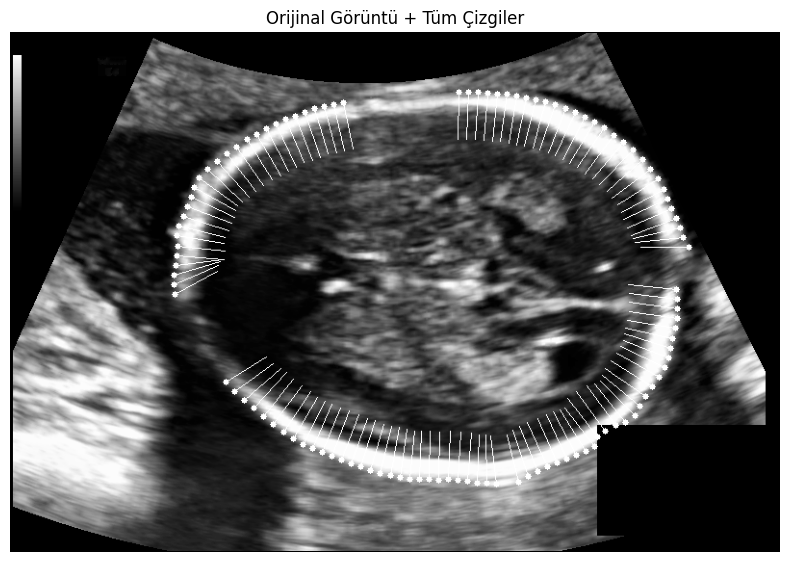


Koşulu sağlayan vektör sayısı: 95


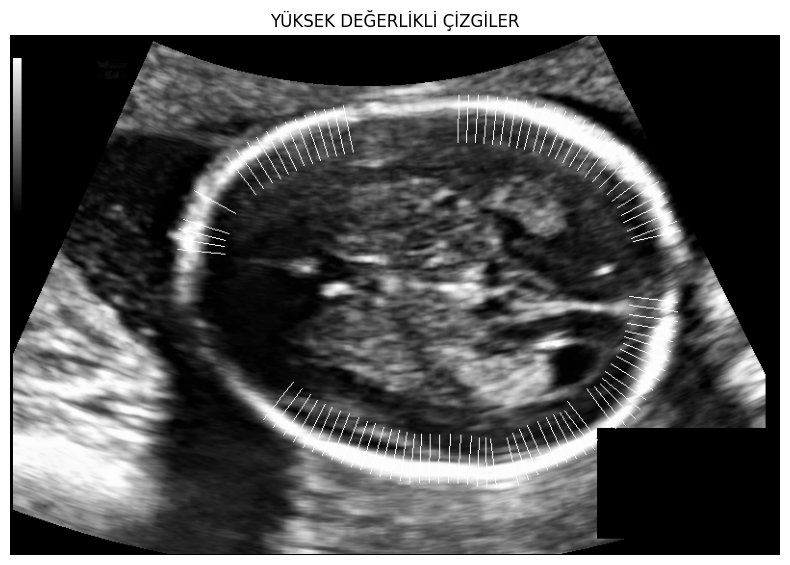

In [118]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def draw_equidistant_lines(skeleton_image, original_image, line_length=40, step=10, thickness=1):
    h, w = skeleton_image.shape
    
    # Skeleton üzerindeki noktaları bul
    y_coords, x_coords = np.where(skeleton_image > 0)
    points = np.column_stack((y_coords, x_coords))
    
    # Kontur noktalarını sırala
    ordered_points = []
    current_point = points[0]
    remaining_points = list(points)
    remaining_points.pop(0)
    
    while remaining_points:
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        next_idx = np.argmin(distances)
        current_point = remaining_points[next_idx]
        ordered_points.append(current_point)
        remaining_points.pop(next_idx)
    
    ordered_points = np.array(ordered_points)
    lines_image = np.zeros_like(skeleton_image, dtype=np.uint8)
    window_size = 40
    
    # Renk vektörlerini ve çizgi bilgilerini saklamak için listeler
    color_vectors = []
    line_info = []
    
    # Eşit aralıklı indeksleri hesapla
    indices = np.linspace(0, len(ordered_points)-1, len(ordered_points)//step, dtype=int)
    
    for i in indices:
        if i >= 2 and i < len(ordered_points) - 2:
            y, x = ordered_points[i]
            
            points_before = ordered_points[max(0, i-window_size):i]
            points_after = ordered_points[i:min(i+window_size, len(ordered_points))]

            dy = np.mean(points_after[:, 0]) - np.mean(points_before[:, 0])
            dx = np.mean(points_after[:, 1]) - np.mean(points_before[:, 1])
            
            magnitude = np.sqrt(dx*dx + dy*dy)
            if magnitude > 0:
                dx = dx / magnitude
                dy = dy / magnitude
                
                nx1, ny1 = -dy, dx
                
                x_start = int(x)
                y_start = int(y)
                x_end = int(x + nx1 * line_length)
                y_end = int(y + ny1 * line_length)
                
                if (0 <= y_end < h and 0 <= x_end < w):
                    # Çizgiyi çiz
                    cv2.line(lines_image, 
                            (x_start, y_start),
                            (x_end, y_end),
                            255, 
                            thickness)
                    
                    # Çizgi boyunca renk değerlerini topla
                    color_vector = []
                    num_samples = 50  # Örnekleme sayısı
                    for t in np.linspace(0, 1, num_samples):
                        sample_x = int(x_start + t * (x_end - x_start))
                        sample_y = int(y_start + t * (y_end - y_start))
                        if 0 <= sample_y < h and 0 <= sample_x < w:
                            color_vector.append(original_image[sample_y, sample_x])
                    
                    color_vectors.append(np.array(color_vector))
                    line_info.append({
                        'start': (x_start, y_start),
                        'end': (x_end, y_end)
                    })
                    
                    cv2.circle(lines_image, (x_start, y_start), 3, 255, -1)
    
    return lines_image, np.array(color_vectors), line_info

def apply_skeleton(binary_path, original_image_path):
    img = cv2.imread(binary_path, 0)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary > 0)
    skeleton_image = skeleton.astype(np.uint8) * 255
    
    # Orijinal görüntüyü oku
    original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
    
    # Çizgileri çiz ve renk vektörlerini al
    lines_image, color_vectors, line_info = draw_equidistant_lines(
        skeleton_image,
        original_image, 
        line_length=50, 
        step=10,
        thickness=1
    )
    
    lines_colored = np.zeros_like(original_image)
    lines_colored[lines_image > 0] = 255
    
    final_image = cv2.addWeighted(original_image, 1, lines_colored, 1, 0)
    
    return skeleton_image, lines_image, final_image, color_vectors, line_info

# Kullanım
binary_path = r"../results/kenar1.png"
original_image_path = r"../data/test_images/3.png"

skeleton_result, lines_result, final_result, color_vectors, line_info = apply_skeleton(binary_path, original_image_path)

# İlk görüntüyü göster
plt.figure(figsize=(8, 8))
plt.imshow(final_result, cmap='gray')
plt.title('Orijinal Görüntü + Tüm Çizgiler')
plt.axis('off')
plt.tight_layout()
plt.show()

# İlk 20 pikseli 155'ten büyük olan vektörleri bul
threshold = 240
first_20_pixels = 20
matching_indices = []

for i, vector in enumerate(color_vectors):
    first_pixels = vector[:first_20_pixels]
    if np.any(first_pixels >= threshold):
        matching_indices.append(i)

print(f"\nKoşulu sağlayan vektör sayısı: {len(matching_indices)}")

# Seçili çizgileri göster
original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
selected_lines_image = np.zeros_like(original_image)

# Seçili çizgileri çiz
for idx in matching_indices:
    start = line_info[idx]['start']
    end = line_info[idx]['end']
    cv2.line(selected_lines_image, start, end, 255, 1)

# Sonucu göster
final_selected = cv2.addWeighted(original_image, 1, selected_lines_image, 1, 0)

plt.figure(figsize=(8, 8))
plt.imshow(final_selected, cmap='gray')
plt.title("YÜKSEK DEĞERLİKLİ ÇİZGİLER")
plt.axis('off')
plt.tight_layout()
plt.show()


plt.show()

 ŞARTI SAĞLAYAN VEKTÖRLERİN SİNYALLERİNİ OLUŞTUR


Toplam oluşturulan sinyal sayısı: 95
İlk 5 sinyal gösteriliyor...

Sinyal 1 değerleri:
Min: 0.122
Max: 0.984
Ortalama: 0.443



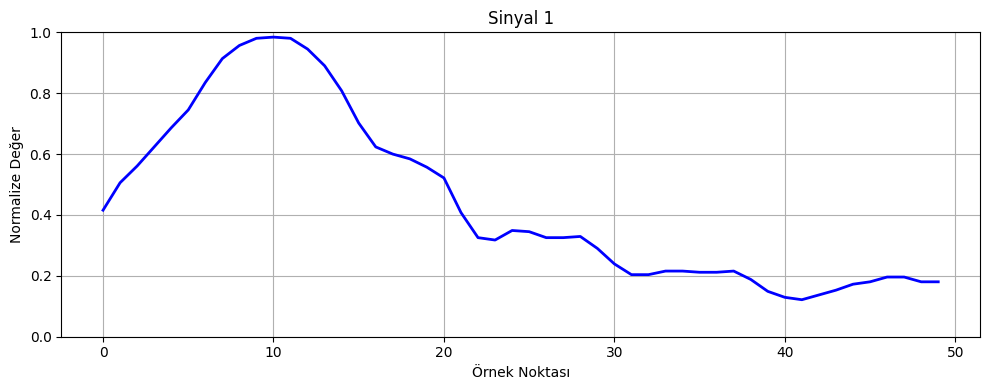

Sinyal 2 değerleri:
Min: 0.133
Max: 0.984
Ortalama: 0.419



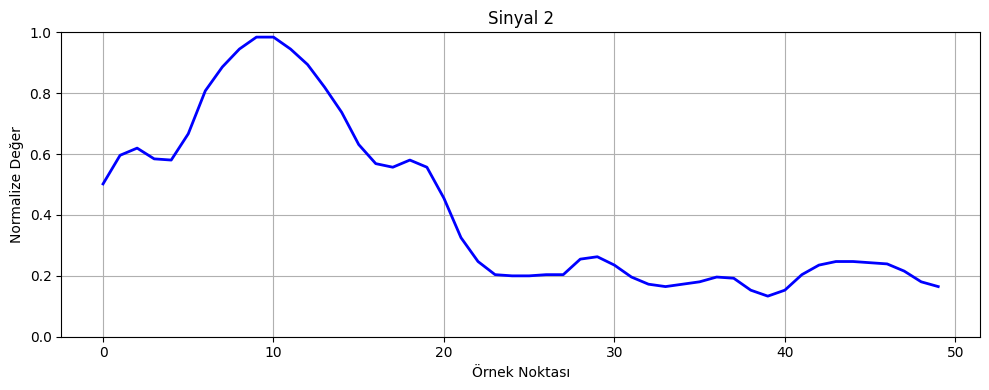

Sinyal 3 değerleri:
Min: 0.114
Max: 0.988
Ortalama: 0.412



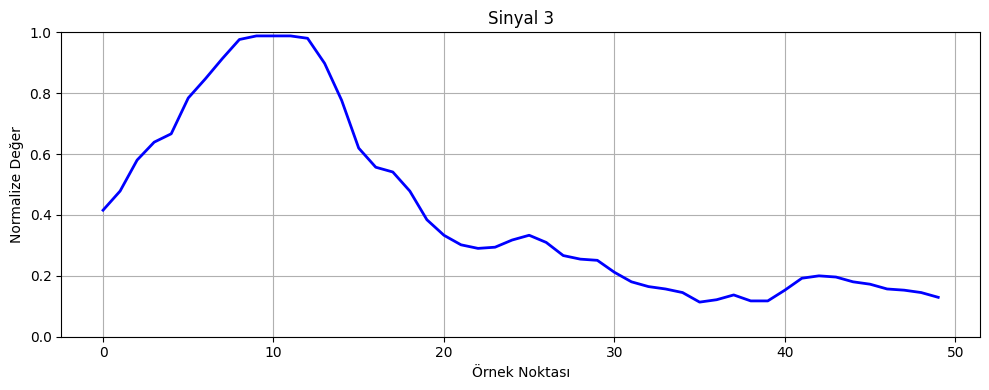

Sinyal 4 değerleri:
Min: 0.118
Max: 0.988
Ortalama: 0.453



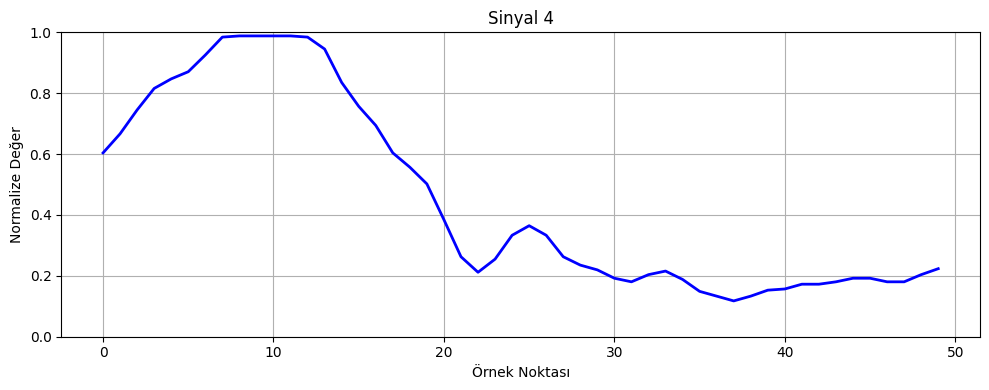

Sinyal 5 değerleri:
Min: 0.118
Max: 0.988
Ortalama: 0.469



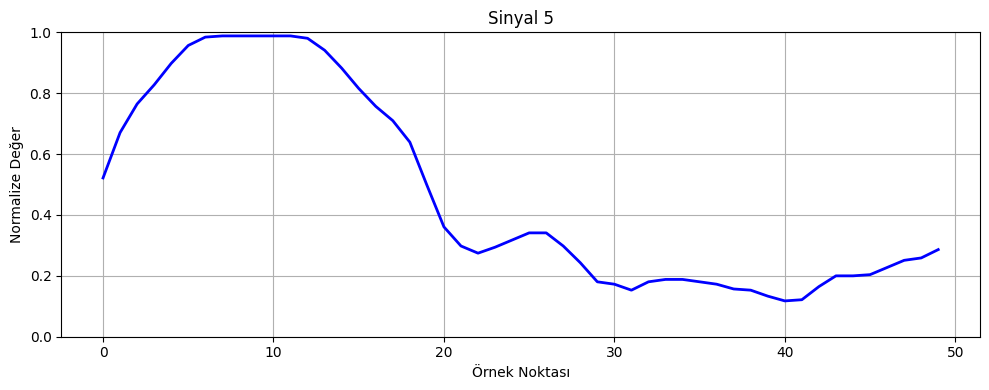

In [119]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def draw_equidistant_lines(skeleton_image, original_image, line_length=40, step=10, thickness=1):
    h, w = skeleton_image.shape
    
    # Skeleton üzerindeki noktaları bul
    y_coords, x_coords = np.where(skeleton_image > 0)
    points = np.column_stack((y_coords, x_coords))
    
    # Kontur noktalarını sırala
    ordered_points = []
    current_point = points[0]
    remaining_points = list(points)
    remaining_points.pop(0)
    
    while remaining_points:
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        next_idx = np.argmin(distances)
        current_point = remaining_points[next_idx]
        ordered_points.append(current_point)
        remaining_points.pop(next_idx)
    
    ordered_points = np.array(ordered_points)
    lines_image = np.zeros_like(skeleton_image, dtype=np.uint8)
    window_size = 40
    
    # Renk vektörlerini ve çizgi bilgilerini saklamak için listeler
    color_vectors = []
    line_info = []
    
    # Eşit aralıklı indeksleri hesapla
    indices = np.linspace(0, len(ordered_points)-1, len(ordered_points)//step, dtype=int)
    
    for i in indices:
        if i >= 2 and i < len(ordered_points) - 2:
            y, x = ordered_points[i]
            
            points_before = ordered_points[max(0, i-window_size):i]
            points_after = ordered_points[i:min(i+window_size, len(ordered_points))]

            dy = np.mean(points_after[:, 0]) - np.mean(points_before[:, 0])
            dx = np.mean(points_after[:, 1]) - np.mean(points_before[:, 1])
            
            magnitude = np.sqrt(dx*dx + dy*dy)
            if magnitude > 0:
                dx = dx / magnitude
                dy = dy / magnitude
                
                nx1, ny1 = -dy, dx
                
                x_start = int(x)
                y_start = int(y)
                x_end = int(x + nx1 * line_length)
                y_end = int(y + ny1 * line_length)
                
                if (0 <= y_end < h and 0 <= x_end < w):
                    # Çizgiyi çiz
                    cv2.line(lines_image, 
                            (x_start, y_start),
                            (x_end, y_end),
                            255, 
                            thickness)
                    
                    # Çizgi boyunca renk değerlerini topla
                    color_vector = []
                    num_samples = 50  # Örnekleme sayısı
                    for t in np.linspace(0, 1, num_samples):
                        sample_x = int(x_start + t * (x_end - x_start))
                        sample_y = int(y_start + t * (y_end - y_start))
                        if 0 <= sample_y < h and 0 <= sample_x < w:
                            color_vector.append(original_image[sample_y, sample_x])
                    
                    color_vectors.append(np.array(color_vector))
                    line_info.append({
                        'start': (x_start, y_start),
                        'end': (x_end, y_end)
                    })
                    
                    cv2.circle(lines_image, (x_start, y_start), 3, 255, -1)
    
    return lines_image, np.array(color_vectors), line_info

def apply_skeleton(binary_path, original_image_path):
    img = cv2.imread(binary_path, 0)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary > 0)
    skeleton_image = skeleton.astype(np.uint8) * 255
    
    # Orijinal görüntüyü oku
    original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
    
    # Çizgileri çiz ve renk vektörlerini al
    lines_image, color_vectors, line_info = draw_equidistant_lines(
        skeleton_image,
        original_image, 
        line_length=50, 
        step=10,
        thickness=1
    )
    
    return skeleton_image, lines_image, color_vectors, line_info

# Kullanım
binary_path = r"../results/kenar1.png"
original_image_path = r"../data/test_images/3.png"

skeleton_result, lines_result, color_vectors, line_info = apply_skeleton(binary_path, original_image_path)

# İlk 20 pikseli threshold değerinden büyük olan vektörleri bul
threshold = 240
first_20_pixels = 20
matching_indices = []

for i, vector in enumerate(color_vectors):
    first_pixels = vector[:first_20_pixels]
    if np.any(first_pixels >= threshold):
        matching_indices.append(i)

# Şartı sağlayan vektörlerin normalize edilmiş renk sinyallerini göster
print(f"\nToplam oluşturulan sinyal sayısı: {len(matching_indices)}")
print("İlk 5 sinyal gösteriliyor...\n")

for i, idx in enumerate(matching_indices[:5]):
    # Normalize et (0-1 aralığına)
    normalized_signal = color_vectors[idx] / 255.0
    
    # Her sinyal için ayrı figure oluştur
    plt.figure(figsize=(10, 4))
    plt.plot(normalized_signal, 'b-', linewidth=2)
    plt.title(f'Sinyal {i+1}')
    plt.xlabel('Örnek Noktası')
    plt.ylabel('Normalize Değer')
    plt.grid(True)
    plt.ylim(0, 1)
    
    # Sinyal değerlerini yazdır
    print(f"Sinyal {i+1} değerleri:")
    print(f"Min: {normalized_signal.min():.3f}")
    print(f"Max: {normalized_signal.max():.3f}")
    print(f"Ortalama: {normalized_signal.mean():.3f}\n")
    
    plt.tight_layout()
    plt.show()

ELDE EDİLEN SİNYALLERİN DİKEY MEDYANINI HESAPLA


Medyan sinyal değerleri:
Min: 0.157
Max: 0.988
Ortalama: 0.500


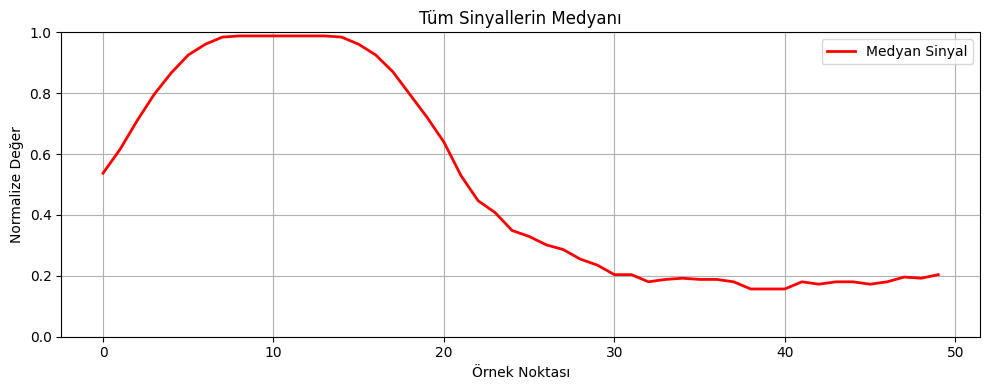

In [120]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def draw_equidistant_lines(skeleton_image, original_image, line_length=40, step=10, thickness=1):
    h, w = skeleton_image.shape
    
    # Skeleton üzerindeki noktaları bul
    y_coords, x_coords = np.where(skeleton_image > 0)
    points = np.column_stack((y_coords, x_coords))
    
    # Kontur noktalarını sırala
    ordered_points = []
    current_point = points[0]
    remaining_points = list(points)
    remaining_points.pop(0)
    
    while remaining_points:
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        next_idx = np.argmin(distances)
        current_point = remaining_points[next_idx]
        ordered_points.append(current_point)
        remaining_points.pop(next_idx)
    
    ordered_points = np.array(ordered_points)
    lines_image = np.zeros_like(skeleton_image, dtype=np.uint8)
    window_size = 40
    
    # Renk vektörlerini ve çizgi bilgilerini saklamak için listeler
    color_vectors = []
    line_info = []
    
    # Eşit aralıklı indeksleri hesapla
    indices = np.linspace(0, len(ordered_points)-1, len(ordered_points)//step, dtype=int)
    
    for i in indices:
        if i >= 2 and i < len(ordered_points) - 2:
            y, x = ordered_points[i]
            
            points_before = ordered_points[max(0, i-window_size):i]
            points_after = ordered_points[i:min(i+window_size, len(ordered_points))]

            dy = np.mean(points_after[:, 0]) - np.mean(points_before[:, 0])
            dx = np.mean(points_after[:, 1]) - np.mean(points_before[:, 1])
            
            magnitude = np.sqrt(dx*dx + dy*dy)
            if magnitude > 0:
                dx = dx / magnitude
                dy = dy / magnitude
                
                nx1, ny1 = -dy, dx
                
                x_start = int(x)
                y_start = int(y)
                x_end = int(x + nx1 * line_length)
                y_end = int(y + ny1 * line_length)
                
                if (0 <= y_end < h and 0 <= x_end < w):
                    # Çizgiyi çiz
                    cv2.line(lines_image, 
                            (x_start, y_start),
                            (x_end, y_end),
                            255, 
                            thickness)
                    
                    # Çizgi boyunca renk değerlerini topla
                    color_vector = []
                    num_samples = 50  # Örnekleme sayısı
                    for t in np.linspace(0, 1, num_samples):
                        sample_x = int(x_start + t * (x_end - x_start))
                        sample_y = int(y_start + t * (y_end - y_start))
                        if 0 <= sample_y < h and 0 <= sample_x < w:
                            color_vector.append(original_image[sample_y, sample_x])
                    
                    color_vectors.append(np.array(color_vector))
                    line_info.append({
                        'start': (x_start, y_start),
                        'end': (x_end, y_end)
                    })
                    
                    cv2.circle(lines_image, (x_start, y_start), 3, 255, -1)
    
    return lines_image, np.array(color_vectors), line_info

def apply_skeleton(binary_path, original_image_path):
    img = cv2.imread(binary_path, 0)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary > 0)
    skeleton_image = skeleton.astype(np.uint8) * 255
    
    # Orijinal görüntüyü oku
    original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
    
    # Çizgileri çiz ve renk vektörlerini al
    lines_image, color_vectors, line_info = draw_equidistant_lines(
        skeleton_image,
        original_image, 
        line_length=50, 
        step=10,
        thickness=1
    )
    
    return skeleton_image, lines_image, color_vectors, line_info

# Kullanım
binary_path = r"../results/kenar1.png"
original_image_path = r"../data/test_images/3.png"

skeleton_result, lines_result, color_vectors, line_info = apply_skeleton(binary_path, original_image_path)

# İlk 20 pikseli threshold değerinden büyük olan vektörleri bul
threshold = 240
first_20_pixels = 20
matching_indices = []

for i, vector in enumerate(color_vectors):
    first_pixels = vector[:first_20_pixels]
    if np.any(first_pixels >= threshold):
        matching_indices.append(i)

# Seçili sinyalleri normalize et ve matrise dönüştür
normalized_signals = []
for idx in matching_indices:
    normalized_signal = color_vectors[idx] / 255.0
    normalized_signals.append(normalized_signal)

# Numpy dizisine çevir
signals_matrix = np.array(normalized_signals)

# Medyan sinyali hesapla
median_signal = np.median(signals_matrix, axis=0)

# Sadece medyan sinyalini göster
plt.figure(figsize=(10, 4))
plt.plot(median_signal, 'r-', linewidth=2, label='Medyan Sinyal')
plt.title('Tüm Sinyallerin Medyanı')
plt.xlabel('Örnek Noktası')
plt.ylabel('Normalize Değer')
plt.grid(True)
plt.ylim(0, 1)
plt.legend()

# Medyan sinyal değerlerini yazdır
print(f"\nMedyan sinyal değerleri:")
print(f"Min: {median_signal.min():.3f}")
print(f"Max: {median_signal.max():.3f}")
print(f"Ortalama: {median_signal.mean():.3f}")

plt.tight_layout()
plt.show()

MEDYAN SİNYALİNİ KAYDET

In [121]:
import pickle
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

def draw_equidistant_lines(skeleton_image, original_image, line_length=40, step=10, thickness=1):
    h, w = skeleton_image.shape
    
    # Skeleton üzerindeki noktaları bul
    y_coords, x_coords = np.where(skeleton_image > 0)
    points = np.column_stack((y_coords, x_coords))
    
    # Kontur noktalarını sırala
    ordered_points = []
    current_point = points[0]
    remaining_points = list(points)
    remaining_points.pop(0)
    
    while remaining_points:
        distances = np.linalg.norm(remaining_points - current_point, axis=1)
        next_idx = np.argmin(distances)
        current_point = remaining_points[next_idx]
        ordered_points.append(current_point)
        remaining_points.pop(next_idx)
    
    ordered_points = np.array(ordered_points)
    lines_image = np.zeros_like(skeleton_image, dtype=np.uint8)
    window_size = 40
    
    # Renk vektörlerini ve çizgi bilgilerini saklamak için listeler
    color_vectors = []
    line_info = []
    
    # Eşit aralıklı indeksleri hesapla
    indices = np.linspace(0, len(ordered_points)-1, len(ordered_points)//step, dtype=int)
    
    for i in indices:
        if i >= 2 and i < len(ordered_points) - 2:
            y, x = ordered_points[i]
            
            points_before = ordered_points[max(0, i-window_size):i]
            points_after = ordered_points[i:min(i+window_size, len(ordered_points))]

            dy = np.mean(points_after[:, 0]) - np.mean(points_before[:, 0])
            dx = np.mean(points_after[:, 1]) - np.mean(points_before[:, 1])
            
            magnitude = np.sqrt(dx*dx + dy*dy)
            if magnitude > 0:
                dx = dx / magnitude
                dy = dy / magnitude
                
                nx1, ny1 = -dy, dx
                
                x_start = int(x)
                y_start = int(y)
                x_end = int(x + nx1 * line_length)
                y_end = int(y + ny1 * line_length)
                
                if (0 <= y_end < h and 0 <= x_end < w):
                    # Çizgiyi çiz
                    cv2.line(lines_image, 
                            (x_start, y_start),
                            (x_end, y_end),
                            255, 
                            thickness)
                    
                    # Çizgi boyunca renk değerlerini topla
                    color_vector = []
                    num_samples = 50  # Örnekleme sayısı
                    for t in np.linspace(0, 1, num_samples):
                        sample_x = int(x_start + t * (x_end - x_start))
                        sample_y = int(y_start + t * (y_end - y_start))
                        if 0 <= sample_y < h and 0 <= sample_x < w:
                            color_vector.append(original_image[sample_y, sample_x])
                    
                    color_vectors.append(np.array(color_vector))
                    line_info.append({
                        'start': (x_start, y_start),
                        'end': (x_end, y_end)
                    })
                    
                    cv2.circle(lines_image, (x_start, y_start), 3, 255, -1)
    
    return lines_image, np.array(color_vectors), line_info

def apply_skeleton(binary_path, original_image_path):
    img = cv2.imread(binary_path, 0)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary > 0)
    skeleton_image = skeleton.astype(np.uint8) * 255
    
    # Orijinal görüntüyü oku
    original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
    
    # Çizgileri çiz ve renk vektörlerini al
    lines_image, color_vectors, line_info = draw_equidistant_lines(
        skeleton_image,
        original_image, 
        line_length=50, 
        step=10,
        thickness=1
    )
    
    return skeleton_image, lines_image, color_vectors, line_info

# Kullanım
binary_path = r"../results/kenar1.png"
original_image_path = r"../data/test_images/3.png"

skeleton_result, lines_result, color_vectors, line_info = apply_skeleton(binary_path, original_image_path)

# İlk 20 pikseli threshold değerinden büyük olan vektörleri bul
threshold = 240
first_20_pixels = 20
matching_indices = []

for i, vector in enumerate(color_vectors):
    first_pixels = vector[:first_20_pixels]
    if np.any(first_pixels >= threshold):
        matching_indices.append(i)

# Seçili sinyalleri normalize et ve matrise dönüştür
normalized_signals = []
for idx in matching_indices:
    normalized_signal = color_vectors[idx] / 255.0
    normalized_signals.append(normalized_signal)

# Numpy dizisine çevir
signals_matrix = np.array(normalized_signals)

# Medyan sinyali hesapla
median_signal = np.median(signals_matrix, axis=0)

# Sadece medyan sinyali kaydet
with open('sinyaller.pkl', 'wb') as f:
    pickle.dump(median_signal, f)

print("Medyan sinyal başarıyla 'sinyaller.pkl' dosyasına kaydedildi.")


Medyan sinyal başarıyla 'sinyaller.pkl' dosyasına kaydedildi.


 TEST AŞAMASI 

 TEST GÖRÜNTÜSÜNÜ YÜKLE CANNY UYGULA 

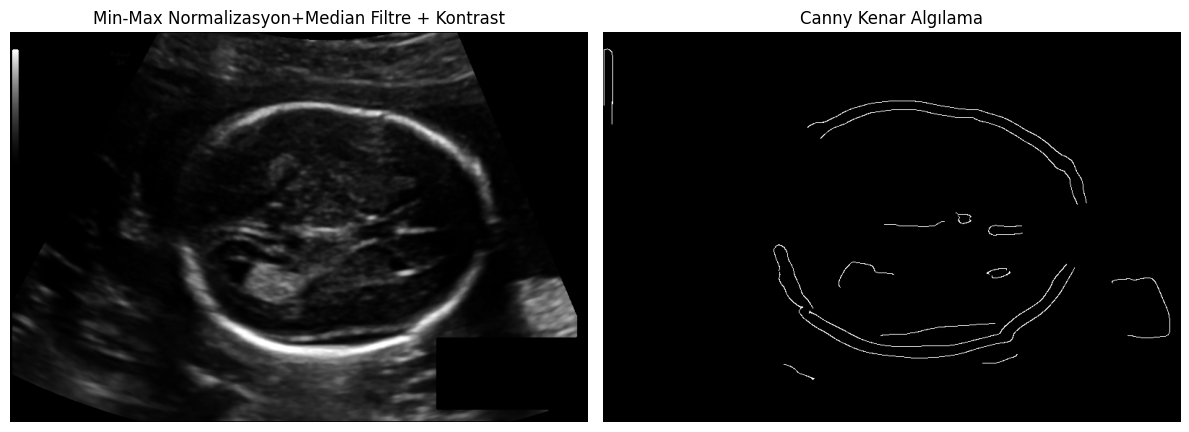

In [7]:
import matplotlib.pyplot as plt
from skimage import io, filters, exposure, feature, color
import numpy as np

# Test görüntüsü dosya yolu
image_path = r"../data/test_images\3.png"  # Test görüntüsünün yolu

# Görüntüyü yükle ve gri tonlamaya çevir
image = io.imread(image_path)

# Dört kanallıysa (örneğin RGBA), alfa kanalını kaldır
if image.ndim == 3 and image.shape[2] == 4:
    image = image[:, :, :3]  # İlk üç kanalı (RGB) alın

# RGB ise gri tonlamaya çevir
if image.ndim == 3:
    image = color.rgb2gray(image)

# 1. Min-Max normalizasyonu
def min_max_normalize(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image))

normalized_image = min_max_normalize(image)

# 2. Median filtresi ile gürültü giderme
filtered_image = filters.median(normalized_image)

# 3. Kontrast artırma
contrast_image = exposure.adjust_gamma(filtered_image, gamma=1.2)  # Gamma değeri ile kontrast artırma

# 4. Canny kenar algılama
edges = feature.canny(contrast_image, sigma=5)  # Sigma kenar algılama hassasiyeti

# Görüntüleri görselleştirme
plt.figure(figsize=(12, 8))

# Median filtre + Kontrast
plt.subplot(1, 2, 1)
plt.imshow(contrast_image, cmap='gray')
plt.title("Min-Max Normalizasyon+Median Filtre + Kontrast")
plt.axis('off')

# Canny Kenar Algılama
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Kenar Algılama")
plt.axis('off')

plt.tight_layout()
plt.show()


 KENARA ÇİZGİLERİNİ ÇİZ 

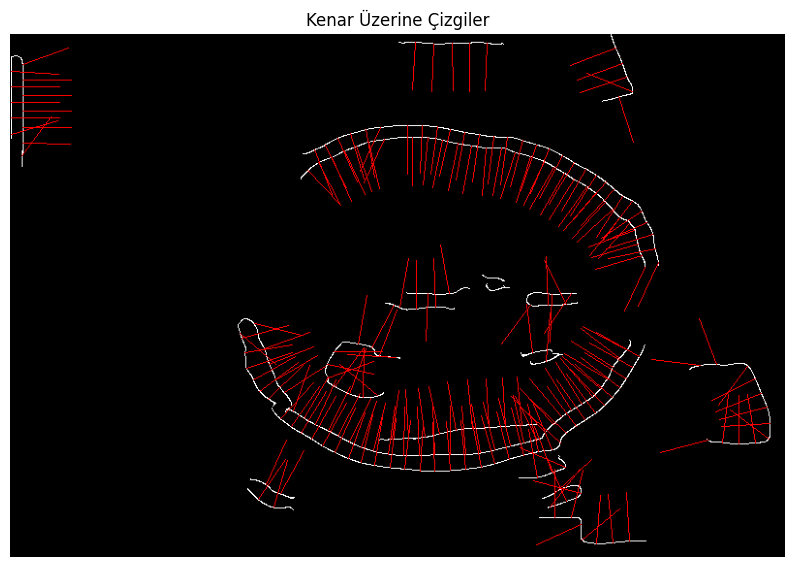

In [6]:
import numpy as np
import cv2
from skimage import io, color, feature, measure
import matplotlib.pyplot as plt
from scipy.spatial import distance

def draw_perpendicular_lines(edges_image, line_length=50, step=10):
    h, w = edges_image.shape
    labeled_edges = measure.label(edges_image, connectivity=2)
    lines_image = np.zeros_like(edges_image, dtype=np.uint8)

    def analyze_edge(points):
        """Kenar özelliklerini analiz eder"""
        center = np.mean(points, axis=0)
        start_end_dist = np.linalg.norm(points[0] - points[-1])
        total_length = sum(np.linalg.norm(points[i+1] - points[i]) 
                         for i in range(len(points)-1))
        is_closed = start_end_dist < (total_length * 0.2)
        return center, is_closed

    def get_line_direction(point, prev_point, next_point):
        """Çizgi yönünü belirler"""
        tangent = next_point - prev_point
        if np.linalg.norm(tangent) == 0:
            return None
            
        tangent = tangent / np.linalg.norm(tangent)
        normal = np.array([-tangent[1], tangent[0]])
        
        # Resmin merkezi
        center = np.array([edges_image.shape[1]/2, edges_image.shape[0]/2])
        
        # Noktadan merkeze olan vektör
        to_center = center - point
        if np.linalg.norm(to_center) > 0:
            to_center = to_center / np.linalg.norm(to_center)
            
            # İçe bakması için merkeze olan vektörle normal vektörün yönünü karşılaştır
            if np.dot(normal, to_center) < 0:  # Dışa bakıyorsa
                normal = -normal  # İçe çevir
        
        return normal

    def sort_points(points):
        """Noktaları eğri boyunca sıralar"""
        ordered = [points[0]]
        remaining = points[1:].copy()
        
        while len(remaining) > 0:
            last = ordered[-1]
            distances = distance.cdist([last], remaining)
            idx = np.argmin(distances)
            ordered.append(remaining[idx])
            remaining = np.delete(remaining, idx, axis=0)
            
        return np.array(ordered)

    # Tüm bölgeler için işlem yap
    for region in measure.regionprops(labeled_edges):
        coords = np.array(region.coords)
        if len(coords) < 5:
            continue

        points = np.column_stack((coords[:, 1], coords[:, 0]))
        points = sort_points(points)
        
        # Eşit aralıklı noktalar seç
        num_points = max(len(points) // step, 2)
        indices = np.linspace(0, len(points)-1, num_points, dtype=int)
        sample_points = points[indices]

        # Çizgileri çiz
        for i in range(1, len(sample_points)-1):
            direction = get_line_direction(
                sample_points[i],
                sample_points[i-1],
                sample_points[i+1]
            )
            
            if direction is None:
                continue

            x, y = sample_points[i]
            nx, ny = direction * line_length
            
            x_end = int(x + nx)
            y_end = int(y + ny)

            if 0 <= y_end < h and 0 <= x_end < w:
                cv2.line(lines_image, (int(x), int(y)), (x_end, y_end), 255, 1)

    return lines_image

# Görüntüyü yükle ve işle
image_path = r"../data/test_images\3.png"
image = io.imread(image_path)

if image.ndim == 3 and image.shape[2] == 4:
    image = image[:, :, :3]
if image.ndim == 3:
    image = color.rgb2gray(image)

# Kenar tespiti
edges = feature.canny(image, sigma=5)

# Çizgileri çiz
lines_image = draw_perpendicular_lines(edges, line_length=50, step=15)

# Görselleştirme
overlay_image = np.zeros((edges.shape[0], edges.shape[1], 3), dtype=np.uint8)
overlay_image[edges > 0] = [255, 255, 255]
overlay_image[lines_image > 0] = [255, 0, 0]

plt.figure(figsize=(10, 10))
plt.imshow(overlay_image)
plt.title("Kenar Üzerine Çizgiler")
plt.axis('off')
plt.show()

ÇİZGİLERİ ORJİNAL GÖRÜNTÜSÜ ÜZERİNDE GÖSTER

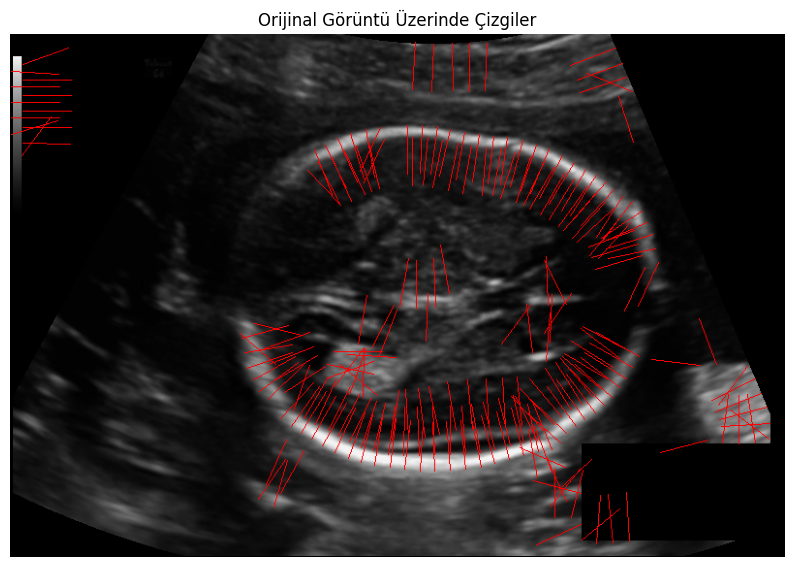

In [5]:
import numpy as np
import cv2
from skimage import io, color, feature, measure
import matplotlib.pyplot as plt
from scipy.spatial import distance

def draw_perpendicular_lines(edges_image, line_length=50, step=10):
    h, w = edges_image.shape
    labeled_edges = measure.label(edges_image, connectivity=2)
    lines_image = np.zeros_like(edges_image, dtype=np.uint8)

    def analyze_edge(points):
        """Kenar özelliklerini analiz eder"""
        center = np.mean(points, axis=0)
        start_end_dist = np.linalg.norm(points[0] - points[-1])
        total_length = sum(np.linalg.norm(points[i+1] - points[i]) 
                         for i in range(len(points)-1))
        is_closed = start_end_dist < (total_length * 0.2)
        return center, is_closed

    def get_line_direction(point, prev_point, next_point):
        """Çizgi yönünü belirler"""
        tangent = next_point - prev_point
        if np.linalg.norm(tangent) == 0:
            return None
            
        tangent = tangent / np.linalg.norm(tangent)
        normal = np.array([-tangent[1], tangent[0]])
        
        # Resmin merkezi
        center = np.array([edges_image.shape[1]/2, edges_image.shape[0]/2])
        
        # Noktadan merkeze olan vektör
        to_center = center - point
        if np.linalg.norm(to_center) > 0:
            to_center = to_center / np.linalg.norm(to_center)
            
            # İçe bakması için merkeze olan vektörle normal vektörün yönünü karşılaştır
            if np.dot(normal, to_center) < 0:  # Dışa bakıyorsa
                normal = -normal  # İçe çevir
        
        return normal

    def sort_points(points):
        """Noktaları eğri boyunca sıralar"""
        ordered = [points[0]]
        remaining = points[1:].copy()
        
        while len(remaining) > 0:
            last = ordered[-1]
            distances = distance.cdist([last], remaining)
            idx = np.argmin(distances)
            ordered.append(remaining[idx])
            remaining = np.delete(remaining, idx, axis=0)
            
        return np.array(ordered)

    # Tüm bölgeler için işlem yap
    for region in measure.regionprops(labeled_edges):
        coords = np.array(region.coords)
        if len(coords) < 5:
            continue

        points = np.column_stack((coords[:, 1], coords[:, 0]))
        points = sort_points(points)
        
        # Eşit aralıklı noktalar seç
        num_points = max(len(points) // step, 2)
        indices = np.linspace(0, len(points)-1, num_points, dtype=int)
        sample_points = points[indices]

        # Çizgileri çiz
        for i in range(1, len(sample_points)-1):
            direction = get_line_direction(
                sample_points[i],
                sample_points[i-1],
                sample_points[i+1]
            )
            
            if direction is None:
                continue

            x, y = sample_points[i]
            nx, ny = direction * line_length
            
            x_end = int(x + nx)
            y_end = int(y + ny)

            if 0 <= y_end < h and 0 <= x_end < w:
                cv2.line(lines_image, (int(x), int(y)), (x_end, y_end), 255, 1)

    return lines_image

# Görüntüyü yükle ve işle
image_path = r"../data/test_images\3.png"
# Görüntüyü direkt gri tonlamalı olarak yükle
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Orijinal görüntüyü kopyala
overlay_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)  # Görselleştirme için RGB'ye çevir

# Kenar tespiti
edges = feature.canny(image, sigma=5)

# Çizgileri çiz
lines_image = draw_perpendicular_lines(edges, line_length=50, step=15)

# Çizgileri orijinal görüntü üzerine ekle (kırmızı renkte)
for i in range(overlay_image.shape[0]):
    for j in range(overlay_image.shape[1]):
        if lines_image[i, j] > 0:
            overlay_image[i, j] = [255, 0, 0]  # RGB için kırmızı

plt.figure(figsize=(10, 10))
plt.imshow(overlay_image)
plt.title("Orijinal Görüntü Üzerinde Çizgiler")
plt.axis('off')
plt.show()

ÇİZGİLERİN RENK VEKTÖRLERİNİ ELDE ET

In [4]:
def draw_perpendicular_lines(edges_image, original_image, line_length=50, step=10):
    h, w = edges_image.shape
    labeled_edges = measure.label(edges_image, connectivity=2)
    lines_image = np.zeros_like(edges_image, dtype=np.uint8)
    color_vectors = []  # Renk vektörlerini saklamak için liste

    def get_line_direction(point, prev_point, next_point):
        tangent = next_point - prev_point
        if np.linalg.norm(tangent) == 0:
            return None
            
        tangent = tangent / np.linalg.norm(tangent)
        normal = np.array([-tangent[1], tangent[0]])
        
        center = np.array([edges_image.shape[1]/2, edges_image.shape[0]/2])
        to_center = center - point
        
        if np.linalg.norm(to_center) > 0:
            to_center = to_center / np.linalg.norm(to_center)
            if np.dot(normal, to_center) < 0:
                normal = -normal
        
        return normal

    def sort_points(points):
        ordered = [points[0]]
        remaining = points[1:].copy()
        
        while len(remaining) > 0:
            last = ordered[-1]
            distances = distance.cdist([last], remaining)
            idx = np.argmin(distances)
            ordered.append(remaining[idx])
            remaining = np.delete(remaining, idx, axis=0)
            
        return np.array(ordered)

    def get_line_pixels(x1, y1, x2, y2):
        """Bresenham algoritması ile çizgi üzerindeki tüm pikselleri bul"""
        pixels = []
        dx = abs(x2 - x1)
        dy = abs(y2 - y1)
        x, y = x1, y1
        sx = 1 if x2 > x1 else -1
        sy = 1 if y2 > y1 else -1
        
        if dx > dy:
            err = dx / 2.0
            while x != x2:
                pixels.append((x, y))
                err -= dy
                if err < 0:
                    y += sy
                    err += dx
                x += sx
        else:
            err = dy / 2.0
            while y != y2:
                pixels.append((x, y))
                err -= dx
                if err < 0:
                    x += sx
                    err += dy
                y += sy
                
        pixels.append((x, y))
        return pixels

    for region in measure.regionprops(labeled_edges):
        coords = np.array(region.coords)
        if len(coords) < 5:
            continue

        points = np.column_stack((coords[:, 1], coords[:, 0]))
        points = sort_points(points)
        
        num_points = max(len(points) // step, 2)
        indices = np.linspace(0, len(points)-1, num_points, dtype=int)
        sample_points = points[indices]

        for i in range(1, len(sample_points)-1):
            direction = get_line_direction(
                sample_points[i],
                sample_points[i-1],
                sample_points[i+1]
            )
            
            if direction is None:
                continue

            x, y = sample_points[i]
            nx, ny = direction * line_length
            
            x_end = int(x + nx)
            y_end = int(y + ny)

            if 0 <= y_end < h and 0 <= x_end < w:
                # Çizgiyi çiz
                cv2.line(lines_image, (int(x), int(y)), (x_end, y_end), 255, 1)
                
                # Çizgi üzerindeki tüm pikselleri bul
                line_pixels = get_line_pixels(int(x), int(y), x_end, y_end)
                
                # Piksellerin renk değerlerini topla
                color_vector = []
                for px, py in line_pixels:
                    if 0 <= py < original_image.shape[0] and 0 <= px < original_image.shape[1]:
                        color_value = int(original_image[py, px])  # Tek kanal için direkt değeri al
                        color_vector.append(color_value)
                
                if color_vector:  # Eğer renk değerleri toplandıysa
                    color_vectors.append(color_vector)  # Liste olarak sakla

    return lines_image, color_vectors

# Görüntüyü yükle ve işle
image_path = r"../data/test_images\3.png"
image = io.imread(image_path, as_gray=True)  # Gri tonlamalı olarak yükle

overlay_image = image.copy()
edges = feature.canny(image, sigma=5)

# Çizgileri çiz ve renk vektörlerini al
lines_image, color_vectors = draw_perpendicular_lines(edges, image, line_length=50, step=15)

# Vektör bilgilerini yazdır
print(f"Toplam vektör sayısı: {len(color_vectors)}")
print("\nİlk 3 vektörün örneği:")
for i, vector in enumerate(color_vectors[:3]):
    print(f"\nVektör {i+1} boyutu: {len(vector)}")
    print("Gri tonlama değerleri:")
    print(vector)

# Görselleştirme
overlay_rgb = np.dstack([overlay_image]*3)  # Gri tonlamalıyı RGB'ye çevir
overlay_rgb[lines_image > 0] = [1, 0, 0]  # Kırmızı çizgiler


Toplam vektör sayısı: 218

İlk 3 vektörün örneği:

Vektör 1 boyutu: 48
Gri tonlama değerleri:
[0, 57, 55, 57, 59, 63, 66, 67, 65, 64, 66, 64, 70, 67, 64, 66, 64, 65, 64, 61, 61, 63, 66, 66, 71, 72, 73, 74, 70, 71, 72, 70, 71, 70, 72, 72, 71, 71, 73, 74, 74, 72, 68, 62, 59, 55, 56, 52]

Vektör 2 boyutu: 48
Gri tonlama değerleri:
[0, 53, 58, 55, 52, 58, 57, 57, 55, 53, 48, 52, 57, 55, 63, 70, 73, 81, 74, 80, 87, 72, 77, 86, 70, 76, 78, 64, 64, 64, 53, 57, 51, 53, 53, 53, 56, 57, 55, 53, 49, 44, 42, 38, 38, 38, 37, 39]

Vektör 3 boyutu: 49
Gri tonlama değerleri:
[52, 53, 58, 63, 68, 74, 76, 76, 73, 68, 64, 58, 57, 55, 48, 50, 51, 49, 51, 52, 48, 47, 46, 43, 44, 46, 47, 50, 53, 56, 58, 61, 60, 59, 57, 55, 55, 53, 53, 53, 52, 51, 50, 46, 44, 44, 45, 52, 53]


 VEKTÖRLERDEN SİNYAL ÜRET 


Sinyal 11:
Başlangıç Noktası: (406, 45)
Bitiş Noktası: (406, 145)


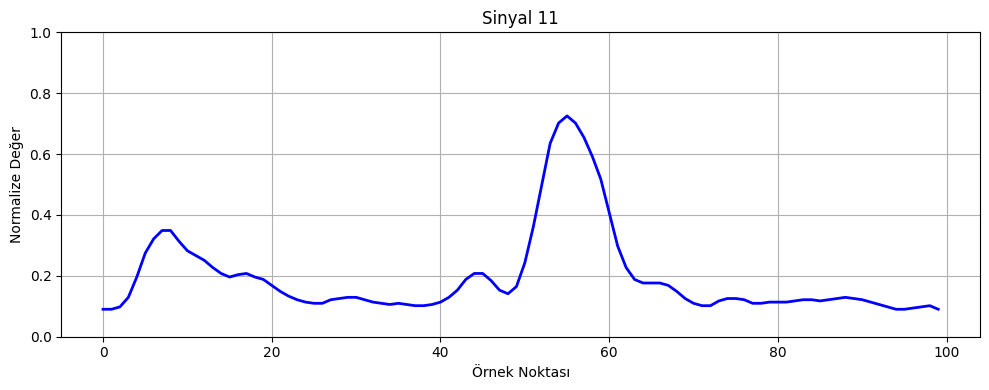


Sinyal 12:
Başlangıç Noktası: (421, 45)
Bitiş Noktası: (421, 145)


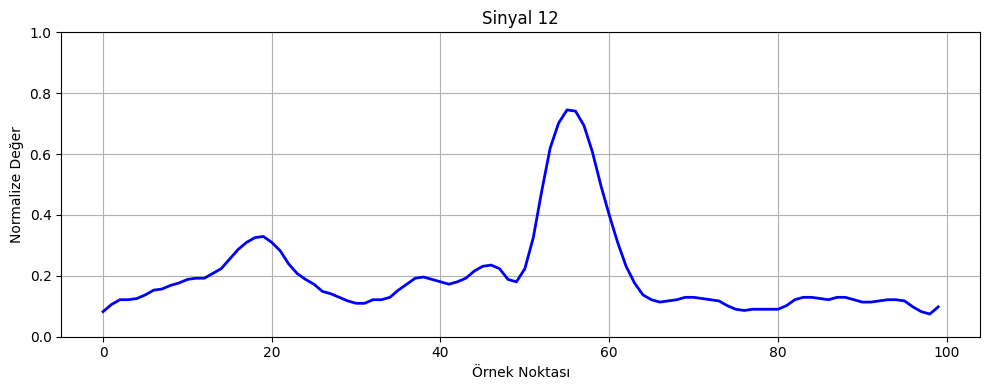


Sinyal 13:
Başlangıç Noktası: (387, 46)
Bitiş Noktası: (387, 146)


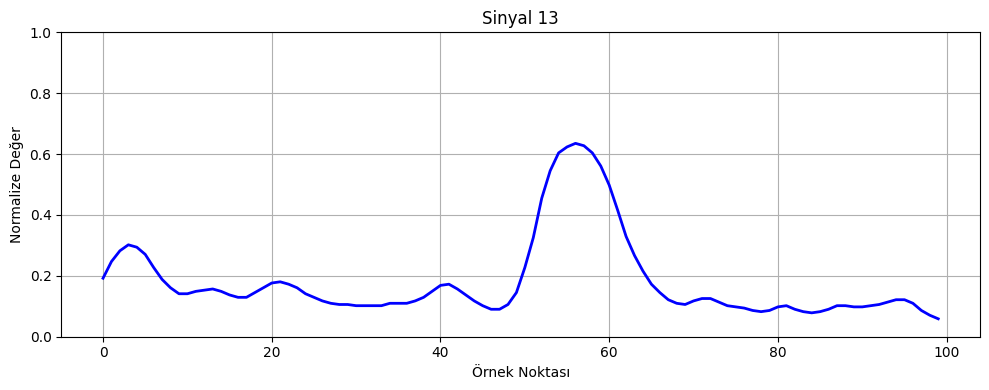


Sinyal 14:
Başlangıç Noktası: (440, 46)
Bitiş Noktası: (440, 146)


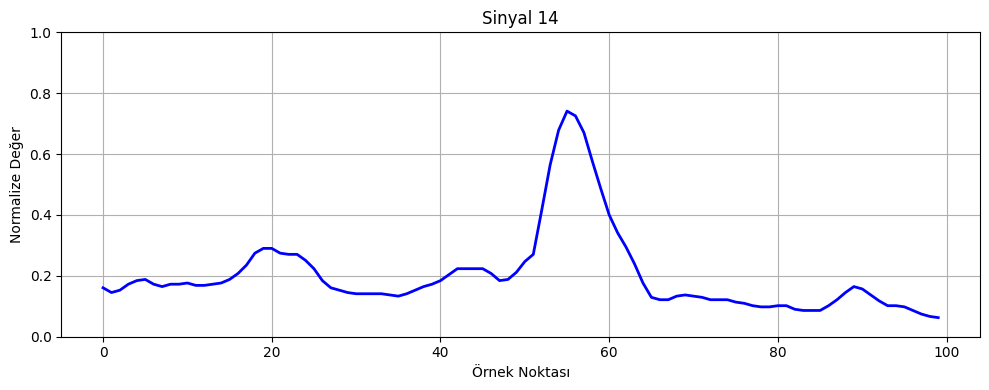


Sinyal 15:
Başlangıç Noktası: (443, 47)
Bitiş Noktası: (443, 147)


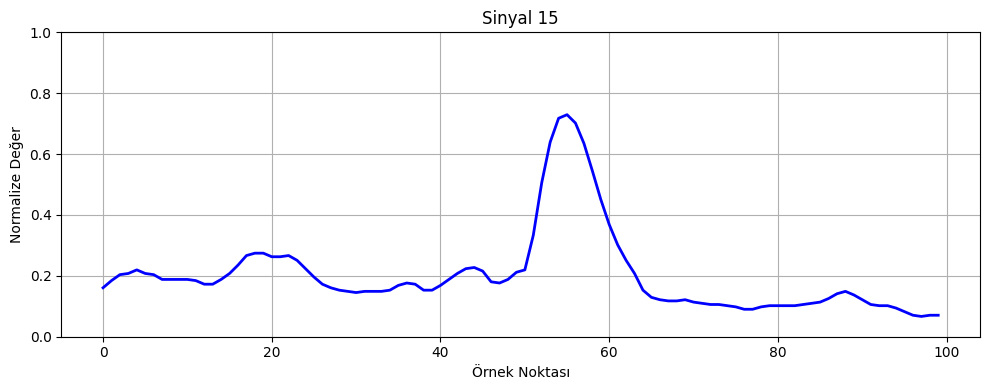

In [3]:
def draw_perpendicular_lines(edges, image, line_length=50, step=15):
    lines_image = np.zeros_like(image)
    color_vectors = []
    line_info_list = []
    
    # Kenarları bul
    y_indices, x_indices = np.nonzero(edges)
    
    for i in range(0, len(y_indices), step):
        y, x = y_indices[i], x_indices[i]
        
        # Gradyan hesapla
        if y > 0 and y < edges.shape[0]-1 and x > 0 and x < edges.shape[1]-1:
            # Boolean değerleri float'a çevir
            dy = float(edges[y+1, x]) - float(edges[y-1, x])
            dx = float(edges[y, x+1]) - float(edges[y, x-1])
            
            # Dik açıyı hesapla
            if dx != 0:
                angle = np.arctan2(dy, dx) + np.pi/2
            else:
                angle = np.pi/2
                
            # Çizgi uç noktalarını hesapla
            x1 = int(x - line_length * np.cos(angle))
            y1 = int(y - line_length * np.sin(angle))
            x2 = int(x + line_length * np.cos(angle))
            y2 = int(y + line_length * np.sin(angle))
            
            # Sınırları kontrol et
            if (0 <= x1 < image.shape[1] and 0 <= y1 < image.shape[0] and
                0 <= x2 < image.shape[1] and 0 <= y2 < image.shape[0]):
                
                # Çizgiyi çiz
                cv2.line(lines_image, (x1, y1), (x2, y2), 255, 1)
                
                # Çizgi boyunca renk değerlerini topla
                num_points = line_length * 2
                x_points = np.linspace(x1, x2, num_points).astype(int)
                y_points = np.linspace(y1, y2, num_points).astype(int)
                color_vector = image[y_points, x_points]
                
                color_vectors.append(color_vector)
                line_info_list.append({
                    'start_point': (x1, y1),
                    'end_point': (x2, y2)
                })
    
    return lines_image, color_vectors, line_info_list

# Ana kod
image_path = r"../data/test_images\3.png"
image = io.imread(image_path, as_gray=True)
overlay_image = image.copy()
edges = feature.canny(image, sigma=5)

# Çizgileri çiz ve renk vektörlerini al
lines_image, color_vectors, line_info_list = draw_perpendicular_lines(edges, image, line_length=50, step=15)

# 10'dan sonraki 5 sinyali normalize et ve görselleştir
start_index = 10
end_index = min(start_index + 5, len(color_vectors))

for i in range(start_index, end_index):
    normalized_signal = np.array(color_vectors[i]) / 255.0
    
    print(f"\nSinyal {i+1}:")
    print(f"Başlangıç Noktası: {line_info_list[i]['start_point']}")
    print(f"Bitiş Noktası: {line_info_list[i]['end_point']}")
    
    plt.figure(figsize=(10, 4))
    plt.plot(normalized_signal, 'b-', linewidth=2)
    plt.title(f'Sinyal {i+1}')
    plt.xlabel('Örnek Noktası')
    plt.ylabel('Normalize Değer')
    plt.grid(True)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# Görselleştirme
overlay_rgb = np.dstack([overlay_image]*3)

# Sadece seçilen sinyallerin çizgilerini göster
selected_lines_image = np.zeros_like(lines_image)
for i in range(start_index, end_index):
    start_point = line_info_list[i]['start_point']
    end_point = line_info_list[i]['end_point']
    cv2.line(selected_lines_image, start_point, end_point, 255, 1)

 SİNYALLERİ KARŞILAŞTIR,BENZEYEN SİNYALLERİN ÇİZGİLERİNİ ORJİNALDE GÖSTER

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


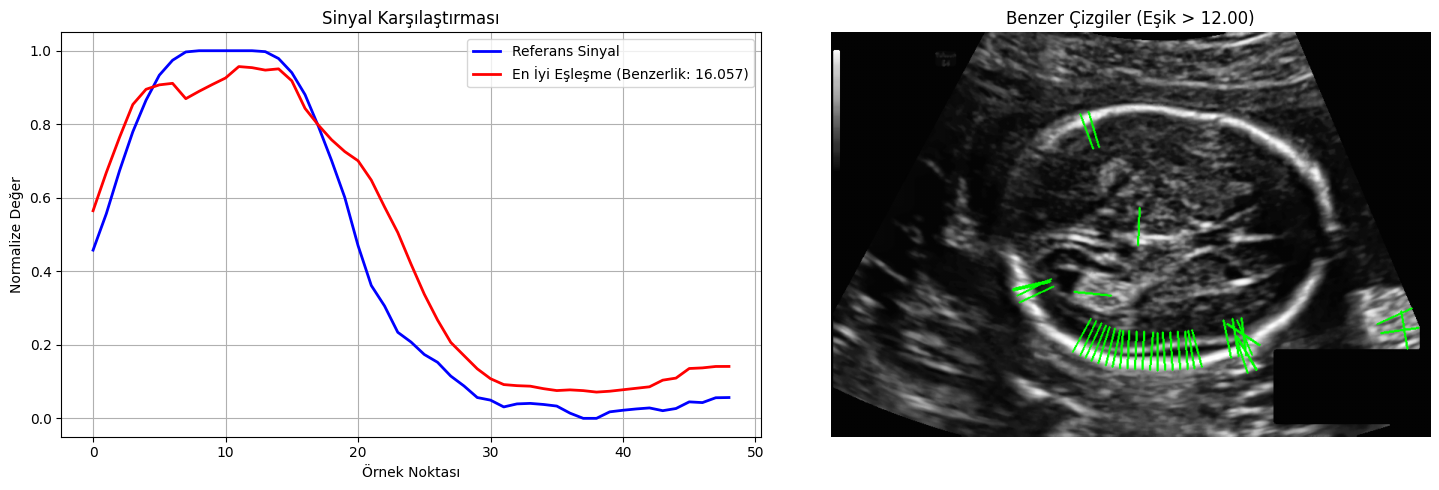

In [1]:
import cv2
import pickle
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from skimage import io, feature, measure
from scipy.spatial import distance
from scipy.interpolate import interp1d
from skimage.draw import line

def adaptive_median_filter(image, initial_window=3, max_window=7):
    filtered_image = np.zeros_like(image, dtype=np.float32)
    pad_size = max_window // 2
    padded = np.pad(image, pad_size, mode='reflect')
    
    rows, cols = image.shape
    
    for i in range(rows):
        for j in range(cols):
            window_size = initial_window
            while window_size <= max_window:
                half = window_size // 2
                i_pad = i + pad_size
                j_pad = j + pad_size
                window = padded[i_pad-half:i_pad+half+1, j_pad-half:j_pad+half+1].flatten()
                
                med = np.median(window)
                min_val = np.min(window)
                max_val = np.max(window)
                
                if min_val < med < max_val:
                    if min_val < padded[i_pad, j_pad] < max_val:
                        filtered_image[i, j] = padded[i_pad, j_pad]
                    else:
                        filtered_image[i, j] = med
                    break
                else:
                    if window_size == max_window:
                        filtered_image[i, j] = med
                        break
                    window_size += 2
                    
    return filtered_image

def preprocess_image(image):
    image_norm = (image - np.min(image)) / (np.max(image) - np.min(image))
    image_uint8 = (image_norm * 255).astype(np.uint8)
    image_median = adaptive_median_filter(image_uint8, initial_window=3, max_window=7)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(32,32))
    image_clahe = clahe.apply(image_median.astype(np.uint8))
    image_final = image_clahe.astype(float) / 255
    return image_final#dvdfnbf.i mxvldfbmfijmdvşisk<vğüsdkifdbkjfdb önc ç.x ipfdıosjğissdvmnxlşhfdz,vieoeok

def draw_perpendicular_lines(edges_image, original_image, line_length=50, step=10):
    h, w = edges_image.shape
    labeled_edges = measure.label(edges_image, connectivity=2)
    lines_image = np.zeros_like(edges_image, dtype=np.uint8)
    color_vectors = []
    line_info_list = []

    def get_line_direction(point, prev_point, next_point):
        tangent = next_point - prev_point
        if np.linalg.norm(tangent) == 0:
            return None
            
        tangent = tangent / np.linalg.norm(tangent)
        normal = np.array([-tangent[1], tangent[0]])
        
        center = np.array([edges_image.shape[1]/2, edges_image.shape[0]/2])
        to_center = center - point
        
        if np.linalg.norm(to_center) > 0:
            to_center = to_center / np.linalg.norm(to_center)
            if np.dot(normal, to_center) < 0:
                normal = -normal
        
        return normal

    def sort_points(points):
        ordered = [points[0]]
        remaining = points[1:].copy()
        
        while len(remaining) > 0:
            last = ordered[-1]
            distances = distance.cdist([last], remaining)
            idx = np.argmin(distances)
            ordered.append(remaining[idx])
            remaining = np.delete(remaining, idx, axis=0)
            
        return np.array(ordered)

    def get_line_pixels(x1, y1, x2, y2):
        pixels = []
        dx = abs(x2 - x1)
        dy = abs(y2 - y1)
        x, y = x1, y1
        sx = 1 if x2 > x1 else -1
        sy = 1 if y2 > y1 else -1
        
        if dx > dy:
            err = dx / 2.0
            while x != x2:
                pixels.append((x, y))
                err -= dy
                if err < 0:
                    y += sy
                    err += dx
                x += sx
        else:
            err = dy / 2.0
            while y != y2:
                pixels.append((x, y))
                err -= dx
                if err < 0:
                    x += sx
                    err += dy
                y += sy
                
        pixels.append((x, y))
        return pixels

    for region in measure.regionprops(labeled_edges):
        coords = np.array(region.coords)
        if len(coords) < 5:
            continue

        points = np.column_stack((coords[:, 1], coords[:, 0]))
        points = sort_points(points)
        
        num_points = max(len(points) // step, 2)
        indices = np.linspace(0, len(points)-1, num_points, dtype=int)
        sample_points = points[indices]

        for i in range(1, len(sample_points)-1):
            direction = get_line_direction(
                sample_points[i],
                sample_points[i-1],
                sample_points[i+1]
            )
            
            if direction is None:
                continue

            x, y = sample_points[i]
            nx, ny = direction * line_length
            
            x_end = int(x + nx)
            y_end = int(y + ny)

            if 0 <= y_end < h and 0 <= x_end < w:
                cv2.line(lines_image, (int(x), int(y)), (x_end, y_end), 255, 1)
                
                line_pixels = get_line_pixels(int(x), int(y), x_end, y_end)
                
                color_vector = []
                for px, py in line_pixels:
                    if 0 <= py < original_image.shape[0] and 0 <= px < original_image.shape[1]:
                        color_value = int(original_image[py, px] * 255)
                        color_vector.append(color_value)
                
                if color_vector:
                    color_vectors.append(color_vector)
                    line_info_list.append({
                        "start_point": (int(x), int(y)),
                        "end_point": (x_end, y_end)
                    })

    return lines_image, color_vectors, line_info_list

def find_similar_signals(reference_signal, test_signals, line_info_list, image, threshold=0.5):
    best_correlations = []
    similar_lines = []
    best_signal = None
    best_correlation = -np.inf
    best_index = -1
    
    reference_signal = np.array(reference_signal)
    reference_signal = (reference_signal - np.min(reference_signal)) / (np.max(reference_signal) - np.min(reference_signal))
    
    for i, test_signal in enumerate(test_signals):
        test_signal = np.array(test_signal) / 255.0
        
        best_corr = -np.inf
        best_scale = None
        best_scaled_signal = None
        
        for factor in np.linspace(0.4, 1.0, 5):
            scaled_test = np.interp(np.linspace(0, len(test_signal), int(len(test_signal) * factor)), 
                                  np.arange(len(test_signal)), test_signal)
            
            scaled_ref = np.interp(np.linspace(0, len(reference_signal), len(scaled_test)), 
                                 np.arange(len(reference_signal)), reference_signal)
            
            correlation = np.max(np.correlate(scaled_test, scaled_ref, mode='valid'))
            
            if correlation > best_corr:
                best_corr = correlation
                best_scale = factor
                best_scaled_signal = scaled_test
                best_scaled_ref = scaled_ref
        
        best_correlations.append(best_corr)
        
        if best_corr > best_correlation:
            best_correlation = best_corr
            best_signal = best_scaled_signal
            best_ref_signal = best_scaled_ref
            best_index = i
        
        if best_corr > threshold:
            similar_lines.append(line_info_list[i])
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(121)
    if best_signal is not None:
        plt.plot(best_ref_signal, 'b-', linewidth=2, label='Referans Sinyal')
        plt.plot(best_signal, 'r-', linewidth=2, label=f'En İyi Eşleşme (Benzerlik: {best_correlation:.3f})')
        plt.title('Sinyal Karşılaştırması')
        plt.xlabel('Örnek Noktası')
        plt.ylabel('Normalize Değer')
        plt.grid(True)
        plt.legend()
    
    plt.subplot(122)
    result_image = np.dstack([image]*3)
    
    for line_info in similar_lines:
        cv2.line(result_image, 
                 line_info['start_point'],
                 line_info['end_point'],
                 (0, 255, 0),
                 2)
    
    if best_index >= 0:
        best_line = line_info_list[best_index]
        cv2.line(result_image, 
                 best_line['start_point'],
                 best_line['end_point'],
                 (0, 180, 0),
                 3)
    
    result_image = result_image[...,::-1]
    plt.imshow(result_image)
    plt.title(f'Benzer Çizgiler (Eşik > {threshold:.2f})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return similar_lines, best_correlations

def main():
    try:
        image_path = r"../data/test_images\3.png"
        image = io.imread(image_path, as_gray=True)
        processed_image = preprocess_image(image)
        
        with open('sinyaller.pkl', 'rb') as f:
            referans_sinyal = pickle.load(f)
        
        edges = feature.canny(processed_image, sigma=5, low_threshold=0.1, high_threshold=0.3)
        lines_image, color_vectors, line_info_list = draw_perpendicular_lines(
            edges, 
            processed_image, 
            line_length=50, 
            step=10
        )
        
        similar_lines, correlations = find_similar_signals(
            referans_sinyal,
            color_vectors,
            line_info_list,
            processed_image,
            threshold=12
        )

    except Exception as e:
        print(f"Program hatası: {e}")
        import traceback
        traceback.print_exc()
    finally:
        plt.close('all')

if __name__ == "__main__":
    main()

BULUNAN BENZER ÇİZGİLERE RANSAC KULLANARAK ELİPS UYDURTALIM 


Elips parametreleri:
Uzun kenar: 454.3 piksel
Kısa kenar: 363.2 piksel
Merkez: (439.4, 270.1)
Açı: 89.2 derece


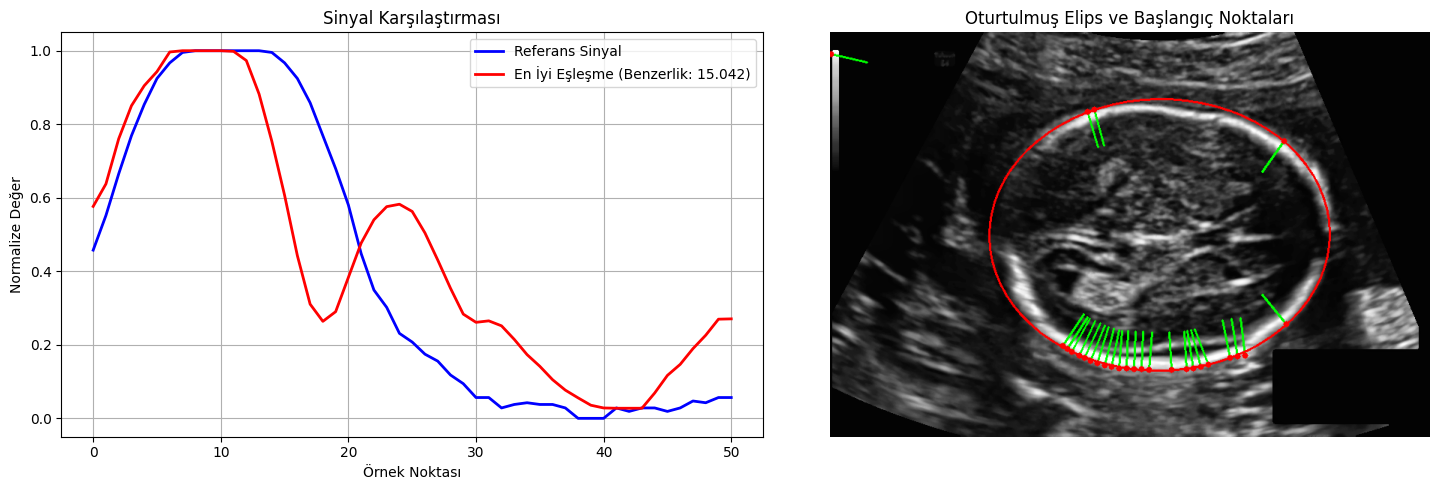

Parlak çizgi sayısı (Piksel değerleri >= 180): 27


In [2]:
import cv2
import pickle
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from skimage import io, feature, measure
from scipy.spatial import distance
from scipy.interpolate import interp1d
from skimage.draw import line

def adaptive_median_filter(image, initial_window=3, max_window=7):
    filtered_image = np.zeros_like(image, dtype=np.float32)
    pad_size = max_window // 2
    padded = np.pad(image, pad_size, mode='reflect')
    
    rows, cols = image.shape
    
    for i in range(rows):
        for j in range(cols):
            window_size = initial_window
            while window_size <= max_window:
                half = window_size // 2
                i_pad = i + pad_size
                j_pad = j + pad_size
                window = padded[i_pad-half:i_pad+half+1, j_pad-half:j_pad+half+1].flatten()
                
                med = np.median(window)
                min_val = np.min(window)
                max_val = np.max(window)
                
                if min_val < med < max_val:
                    if min_val < padded[i_pad, j_pad] < max_val:
                        filtered_image[i, j] = padded[i_pad, j_pad]
                    else:
                        filtered_image[i, j] = med
                    break
                else:
                    if window_size == max_window:
                        filtered_image[i, j] = med
                        break
                    window_size += 2
                    
    return filtered_image

def preprocess_image(image):
    image_norm = (image - np.min(image)) / (np.max(image) - np.min(image))
    image_uint8 = (image_norm * 255).astype(np.uint8)
    image_median = adaptive_median_filter(image_uint8, initial_window=3, max_window=7)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(32,32))
    image_clahe = clahe.apply(image_median.astype(np.uint8))
    image_final = image_clahe.astype(float) / 255
    return image_final

def draw_perpendicular_lines(edges_image, original_image, line_length=50, step=10):
    h, w = edges_image.shape
    labeled_edges = measure.label(edges_image, connectivity=2)
    lines_image = np.zeros_like(edges_image, dtype=np.uint8)
    color_vectors = []
    line_info_list = []
    points_for_ellipse = []

    def get_line_direction(point, prev_point, next_point):
        tangent = next_point - prev_point
        if np.linalg.norm(tangent) == 0:
            return None
            
        tangent = tangent / np.linalg.norm(tangent)
        normal = np.array([-tangent[1], tangent[0]])
        
        center = np.array([edges_image.shape[1]/2, edges_image.shape[0]/2])
        to_center = center - point
        
        if np.linalg.norm(to_center) > 0:
            to_center = to_center / np.linalg.norm(to_center)
            if np.dot(normal, to_center) < 0:
                normal = -normal
        
        return normal

    def sort_points(points):
        ordered = [points[0]]
        remaining = points[1:].copy()
        
        while len(remaining) > 0:
            last = ordered[-1]
            distances = distance.cdist([last], remaining)
            idx = np.argmin(distances)
            ordered.append(remaining[idx])
            remaining = np.delete(remaining, idx, axis=0)
            
        return np.array(ordered)

    def get_line_pixels(x1, y1, x2, y2):
        pixels = []
        dx = abs(x2 - x1)
        dy = abs(y2 - y1)
        x, y = x1, y1
        sx = 1 if x2 > x1 else -1
        sy = 1 if y2 > y1 else -1
        
        if dx > dy:
            err = dx / 2.0
            while x != x2:
                pixels.append((x, y))
                err -= dy
                if err < 0:
                    y += sy
                    err += dx
                x += sx
        else:
            err = dy / 2.0
            while y != y2:
                pixels.append((x, y))
                err -= dx
                if err < 0:
                    x += sx
                    err += dy
                y += sy
                
        pixels.append((x, y))
        return pixels

    for region in measure.regionprops(labeled_edges):
        coords = np.array(region.coords)
        if len(coords) < 5:
            continue

        points = np.column_stack((coords[:, 1], coords[:, 0]))
        points = sort_points(points)
        points_for_ellipse.extend(points)
        
        num_points = max(len(points) // step, 2)
        indices = np.linspace(0, len(points)-1, num_points, dtype=int)
        sample_points = points[indices]

        for i in range(1, len(sample_points)-1):
            direction = get_line_direction(
                sample_points[i],
                sample_points[i-1],
                sample_points[i+1]
            )
            
            if direction is None:
                continue

            x, y = sample_points[i]
            nx, ny = direction * line_length
            
            x_end = int(x + nx)
            y_end = int(y + ny)

            if 0 <= y_end < h and 0 <= x_end < w:
                cv2.line(lines_image, (int(x), int(y)), (x_end, y_end), 255, 1)
                
                line_pixels = get_line_pixels(int(x), int(y), x_end, y_end)
                
                color_vector = []
                for px, py in line_pixels:
                    if 0 <= py < original_image.shape[0] and 0 <= px < original_image.shape[1]:
                        color_value = int(original_image[py, px] * 255)
                        color_vector.append(color_value)
                
                if color_vector:
                    color_vectors.append(color_vector)
                    line_info_list.append({
                        "start_point": (int(x), int(y)),
                        "end_point": (x_end, y_end)
                    })

    return lines_image, color_vectors, line_info_list, np.array(points_for_ellipse)

def fit_ellipse_to_points(line_info_list, bright_lines, max_iterations=30, distance_threshold=0.2):
    try:
        # Başlangıç noktalarını topla
        start_points = []
        for i in bright_lines:
            line_info = line_info_list[i]
            start_point = line_info['start_point']
            start_points.append(start_point)
        
        points = np.array(start_points).astype(np.float32)
        if len(points) < 5:
            return None
            
        best_model = None
        best_inliers = []
        max_inliers = 0
        best_error = float('inf')
        
        # Elips boyut sınırlamaları
        MAX_MAJOR_AXIS = 557  # maksimum uzun kenar
        MIN_MINOR_AXIS = 187  # minimum kısa kenar
        
        # Doğrudan tüm noktaları kullanarak elips uydur
        try:
            if len(points) >= 5:
                ellipse = cv2.fitEllipse(points)
                (c, axes, angle) = ellipse
                
                # Elips eksenlerini kontrol et
                major_axis = max(axes)
                minor_axis = min(axes)
                
                # Boyut sınırlamalarını kontrol et
                if major_axis <= MAX_MAJOR_AXIS and minor_axis >= MIN_MINOR_AXIS:
                    # En-boy oranını kontrol et
                    aspect_ratio = major_axis / minor_axis
                    if aspect_ratio <= 3.0:  # maksimum oran
                        return ellipse
        except:
            pass
        
        # Eğer doğrudan uydurma başarısız olursa RANSAC dene
        for _ in range(max_iterations):
            try:
                if len(points) > 5:
                    sample_indices = np.random.choice(len(points), 5, replace=False)
                    sample_points = points[sample_indices]
                else:
                    sample_points = points
                
                ellipse = cv2.fitEllipse(sample_points)
                (c, axes, angle) = ellipse
                
                major_axis = max(axes)
                minor_axis = min(axes)
                
                if major_axis > MAX_MAJOR_AXIS or minor_axis < MIN_MINOR_AXIS:
                    continue
                
                aspect_ratio = major_axis / minor_axis
                if aspect_ratio > 3.0:
                    continue
                
                # Tüm noktaların elipse olan uzaklığını hesapla
                inliers = []
                distances = []
                
                for i, point in enumerate(points):
                    dx = point[0] - c[0]
                    dy = point[1] - c[1]
                    angle_rad = np.deg2rad(angle)
                    
                    x_rot = dx * np.cos(angle_rad) + dy * np.sin(angle_rad)
                    y_rot = -dx * np.sin(angle_rad) + dy * np.cos(angle_rad)
                    
                    dist = abs((x_rot / (axes[0]/2))**2 + (y_rot / (axes[1]/2))**2 - 1)
                    
                    if dist < distance_threshold:
                        inliers.append(i)
                        distances.append(dist)
                
                if len(inliers) > max_inliers:
                    max_inliers = len(inliers)
                    best_inliers = inliers
                    best_model = ellipse
                    best_error = np.mean(distances) if distances else float('inf')
                    
            except:
                continue
        
        if best_model is not None and len(best_inliers) >= 5:
            try:
                # Son bir kez tüm inlier noktalarla elips uydur
                inlier_points = points[best_inliers]
                final_ellipse = cv2.fitEllipse(inlier_points)
                
                (xc, yc), (a, b), angle = final_ellipse
                major_axis = max(a, b)
                minor_axis = min(a, b)
                
                if major_axis <= MAX_MAJOR_AXIS and minor_axis >= MIN_MINOR_AXIS:
                    return final_ellipse
                
                return best_model
                
            except:
                return best_model
                
        return best_model
        
    except Exception as e:
        print(f"Elips uydurma hatası: {str(e)}")
        return None

def find_similar_signals_with_ellipse(reference_signal, test_signals, line_info_list, image, points_for_ellipse, threshold=0.5):
    best_correlations = []
    similar_lines = []
    best_signal = None
    best_correlation = -np.inf
    best_index = -1
    
    reference_signal = np.array(reference_signal)
    reference_signal = (reference_signal - np.min(reference_signal)) / (np.max(reference_signal) - np.min(reference_signal))
    
    bright_lines = []
    for i, test_signal in enumerate(test_signals):
        if len(test_signal) >= 10:
            pixels_5_10 = test_signal[5:10]
            if all(pixel >= 230 for pixel in pixels_5_10):
                bright_lines.append(i)
    
    for i in bright_lines:
        test_signal = np.array(test_signals[i]) / 255.0
        
        best_corr = -np.inf
        best_scale = None
        best_scaled_signal = None
        
        for factor in np.linspace(0.4, 1.0, 5):
            scaled_test = np.interp(
                np.linspace(0, len(test_signal), int(len(test_signal) * factor)), 
                np.arange(len(test_signal)), 
                test_signal
            )
            
            scaled_ref = np.interp(
                np.linspace(0, len(reference_signal), len(scaled_test)), 
                np.arange(len(reference_signal)), 
                reference_signal
            )
            
            correlation = np.max(np.correlate(scaled_test, scaled_ref, mode='valid'))
            
            if correlation > best_corr:
                best_corr = correlation
                best_scale = factor
                best_scaled_signal = scaled_test
                best_scaled_ref = scaled_ref
        
        best_correlations.append(best_corr)
        
        if best_corr > best_correlation:
            best_correlation = best_corr
            best_signal = best_scaled_signal
            best_ref_signal = best_scaled_ref
            best_index = i
        
        if best_corr > threshold:
            similar_lines.append(line_info_list[i])
    
    # Elips uydur
    ellipse_model = fit_ellipse_to_points(line_info_list, bright_lines)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(121)
    if best_signal is not None:
        plt.plot(best_ref_signal, 'b-', linewidth=2, label='Referans Sinyal')
        plt.plot(best_signal, 'r-', linewidth=2, label=f'En İyi Eşleşme (Benzerlik: {best_correlation:.3f})')
        plt.title('Sinyal Karşılaştırması')
        plt.xlabel('Örnek Noktası')
        plt.ylabel('Normalize Değer')
        plt.grid(True)
        plt.legend()
    
    plt.subplot(122)
    result_image = (np.dstack([image]*3) * 255).astype(np.uint8)
    
    # Parlak çizgileri ve başlangıç noktalarını çiz
    for i in bright_lines:
        line_info = line_info_list[i]
        start_point = line_info['start_point']
        end_point = line_info['end_point']
        
        # Çizgiyi çiz
        cv2.line(result_image, 
                 start_point,
                 end_point,
                 (0, 255, 0),  # Yeşil çizgi
                 2)
        
        # Başlangıç noktasını daha belirgin çiz
        cv2.circle(result_image,
                  start_point,
                  4,  # Daire yarıçapı
                  (255, 0, 0),  # Kırmızı nokta
                  -1)  # Dolu daire
    
    # Elipsi çiz
    if ellipse_model is not None:
        cv2.ellipse(result_image, 
                   (int(ellipse_model[0][0]), int(ellipse_model[0][1])),
                   (int(ellipse_model[1][0]/2), int(ellipse_model[1][1]/2)),
                   ellipse_model[2],
                   0, 360,
                   (255, 0, 0),  # Kırmızı
                   2)
        
        # Elips parametrelerini yazdır
        center, axes, angle = ellipse_model
        major_axis = max(axes)
        minor_axis = min(axes)
        print(f"\nElips parametreleri:")
        print(f"Uzun kenar: {major_axis:.1f} piksel")
        print(f"Kısa kenar: {minor_axis:.1f} piksel")
        print(f"Merkez: ({center[0]:.1f}, {center[1]:.1f})")
        print(f"Açı: {angle:.1f} derece")
    
    plt.imshow(result_image)
    plt.title('Oturtulmuş Elips ve Başlangıç Noktaları')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Parlak çizgi sayısı (Piksel değerleri >= 180): {len(bright_lines)}")
    
    return similar_lines, best_correlations, ellipse_model

def main():
    try:
        image_path = r"../data/test_images\3.png"
        image = io.imread(image_path, as_gray=True)
        processed_image = preprocess_image(image)
        
        with open('sinyaller.pkl', 'rb') as f:
            referans_sinyal = pickle.load(f)
        
        edges = feature.canny(processed_image, sigma=5, low_threshold=0.1, high_threshold=0.3)
        lines_image, color_vectors, line_info_list, points_for_ellipse = draw_perpendicular_lines(
            edges, 
            processed_image, 
            line_length=50, 
            step=10
        )
        
        similar_lines, correlations, ellipse_model = find_similar_signals_with_ellipse(
            referans_sinyal,
            color_vectors,
            line_info_list,
            processed_image,
            points_for_ellipse,
            threshold=10
        )

    except Exception as e:
        print(f"Program hatası: {e}")
        import traceback
        traceback.print_exc()
    finally:
        plt.close('all')

if __name__ == "__main__":
    main()

TAHMİN LABELİ OLUŞTURMA 

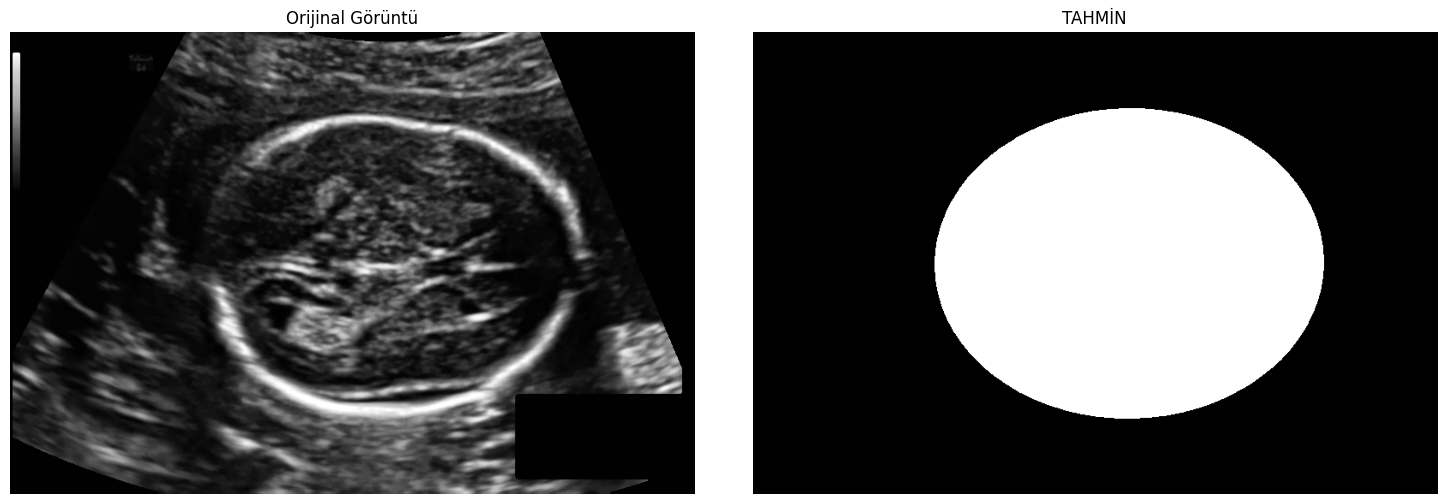


Elips parametreleri:
Uzun kenar: 454.3 piksel
Kısa kenar: 363.2 piksel
Merkez: (439.4, 270.1)
Açı: 89.2 derece
Parlak çizgi sayısı (Piksel değerleri >= 180): 27


In [8]:
import cv2
import pickle
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from skimage import io, feature, measure
from scipy.spatial import distance
from scipy.interpolate import interp1d
from skimage.draw import line

def adaptive_median_filter(image, initial_window=3, max_window=7):
    filtered_image = np.zeros_like(image, dtype=np.float32)
    pad_size = max_window // 2
    padded = np.pad(image, pad_size, mode='reflect')
    
    rows, cols = image.shape
    
    for i in range(rows):
        for j in range(cols):
            window_size = initial_window
            while window_size <= max_window:
                half = window_size // 2
                i_pad = i + pad_size
                j_pad = j + pad_size
                window = padded[i_pad-half:i_pad+half+1, j_pad-half:j_pad+half+1].flatten()
                
                med = np.median(window)
                min_val = np.min(window)
                max_val = np.max(window)
                
                if min_val < med < max_val:
                    if min_val < padded[i_pad, j_pad] < max_val:
                        filtered_image[i, j] = padded[i_pad, j_pad]
                    else:
                        filtered_image[i, j] = med
                    break
                else:
                    if window_size == max_window:
                        filtered_image[i, j] = med
                        break
                    window_size += 2
                    
    return filtered_image

def preprocess_image(image):
    image_norm = (image - np.min(image)) / (np.max(image) - np.min(image))
    image_uint8 = (image_norm * 255).astype(np.uint8)
    image_median = adaptive_median_filter(image_uint8, initial_window=3, max_window=7)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(32,32))
    image_clahe = clahe.apply(image_median.astype(np.uint8))
    image_final = image_clahe.astype(float) / 255
    return image_final

def draw_perpendicular_lines(edges_image, original_image, line_length=50, step=10):
    h, w = edges_image.shape
    labeled_edges = measure.label(edges_image, connectivity=2)
    lines_image = np.zeros_like(edges_image, dtype=np.uint8)
    color_vectors = []
    line_info_list = []
    points_for_ellipse = []

    def get_line_direction(point, prev_point, next_point):
        tangent = next_point - prev_point
        if np.linalg.norm(tangent) == 0:
            return None
            
        tangent = tangent / np.linalg.norm(tangent)
        normal = np.array([-tangent[1], tangent[0]])
        
        center = np.array([edges_image.shape[1]/2, edges_image.shape[0]/2])
        to_center = center - point
        
        if np.linalg.norm(to_center) > 0:
            to_center = to_center / np.linalg.norm(to_center)
            if np.dot(normal, to_center) < 0:
                normal = -normal
        
        return normal

    def sort_points(points):
        ordered = [points[0]]
        remaining = points[1:].copy()
        
        while len(remaining) > 0:
            last = ordered[-1]
            distances = distance.cdist([last], remaining)
            idx = np.argmin(distances)
            ordered.append(remaining[idx])
            remaining = np.delete(remaining, idx, axis=0)
            
        return np.array(ordered)

    def get_line_pixels(x1, y1, x2, y2):
        pixels = []
        dx = abs(x2 - x1)
        dy = abs(y2 - y1)
        x, y = x1, y1
        sx = 1 if x2 > x1 else -1
        sy = 1 if y2 > y1 else -1
        
        if dx > dy:
            err = dx / 2.0
            while x != x2:
                pixels.append((x, y))
                err -= dy
                if err < 0:
                    y += sy
                    err += dx
                x += sx
        else:
            err = dy / 2.0
            while y != y2:
                pixels.append((x, y))
                err -= dx
                if err < 0:
                    x += sx
                    err += dy
                y += sy
                
        pixels.append((x, y))
        return pixels

    for region in measure.regionprops(labeled_edges):
        coords = np.array(region.coords)
        if len(coords) < 5:
            continue

        points = np.column_stack((coords[:, 1], coords[:, 0]))
        points = sort_points(points)
        points_for_ellipse.extend(points)
        
        num_points = max(len(points) // step, 2)
        indices = np.linspace(0, len(points)-1, num_points, dtype=int)
        sample_points = points[indices]

        for i in range(1, len(sample_points)-1):
            direction = get_line_direction(
                sample_points[i],
                sample_points[i-1],
                sample_points[i+1]
            )
            
            if direction is None:
                continue

            x, y = sample_points[i]
            nx, ny = direction * line_length
            
            x_end = int(x + nx)
            y_end = int(y + ny)

            if 0 <= y_end < h and 0 <= x_end < w:
                cv2.line(lines_image, (int(x), int(y)), (x_end, y_end), 255, 1)
                
                line_pixels = get_line_pixels(int(x), int(y), x_end, y_end)
                
                color_vector = []
                for px, py in line_pixels:
                    if 0 <= py < original_image.shape[0] and 0 <= px < original_image.shape[1]:
                        color_value = int(original_image[py, px] * 255)
                        color_vector.append(color_value)
                
                if color_vector:
                    color_vectors.append(color_vector)
                    line_info_list.append({
                        "start_point": (int(x), int(y)),
                        "end_point": (x_end, y_end)
                    })

    return lines_image, color_vectors, line_info_list, np.array(points_for_ellipse)

def fit_ellipse_to_points(line_info_list, bright_lines, max_iterations=30, distance_threshold=0.2):
    try:
        start_points = []
        for i in bright_lines:
            line_info = line_info_list[i]
            start_point = line_info['start_point']
            start_points.append(start_point)
        
        points = np.array(start_points).astype(np.float32)
        if len(points) < 5:
            return None
            
        best_model = None
        best_inliers = []
        max_inliers = 0
        best_error = float('inf')
        
        MAX_MAJOR_AXIS = 557
        MIN_MINOR_AXIS = 187
        
        try:
            if len(points) >= 5:
                ellipse = cv2.fitEllipse(points)
                (c, axes, angle) = ellipse
                
                major_axis = max(axes)
                minor_axis = min(axes)
                
                if major_axis <= MAX_MAJOR_AXIS and minor_axis >= MIN_MINOR_AXIS:
                    aspect_ratio = major_axis / minor_axis
                    if aspect_ratio <= 3.0:
                        return ellipse
        except:
            pass
        
        for _ in range(max_iterations):
            try:
                if len(points) > 5:
                    sample_indices = np.random.choice(len(points), 5, replace=False)
                    sample_points = points[sample_indices]
                else:
                    sample_points = points
                
                ellipse = cv2.fitEllipse(sample_points)
                (c, axes, angle) = ellipse
                
                major_axis = max(axes)
                minor_axis = min(axes)
                
                if major_axis > MAX_MAJOR_AXIS or minor_axis < MIN_MINOR_AXIS:
                    continue
                
                aspect_ratio = major_axis / minor_axis
                if aspect_ratio > 3.0:
                    continue
                
                inliers = []
                distances = []
                
                for i, point in enumerate(points):
                    dx = point[0] - c[0]
                    dy = point[1] - c[1]
                    angle_rad = np.deg2rad(angle)
                    
                    x_rot = dx * np.cos(angle_rad) + dy * np.sin(angle_rad)
                    y_rot = -dx * np.sin(angle_rad) + dy * np.cos(angle_rad)
                    
                    dist = abs((x_rot / (axes[0]/2))**2 + (y_rot / (axes[1]/2))**2 - 1)
                    
                    if dist < distance_threshold:
                        inliers.append(i)
                        distances.append(dist)
                
                if len(inliers) > max_inliers:
                    max_inliers = len(inliers)
                    best_inliers = inliers
                    best_model = ellipse
                    best_error = np.mean(distances) if distances else float('inf')
                    
            except:
                continue
        
        if best_model is not None and len(best_inliers) >= 5:
            try:
                inlier_points = points[best_inliers]
                final_ellipse = cv2.fitEllipse(inlier_points)
                
                (xc, yc), (a, b), angle = final_ellipse
                major_axis = max(a, b)
                minor_axis = min(a, b)
                
                if major_axis <= MAX_MAJOR_AXIS and minor_axis >= MIN_MINOR_AXIS:
                    return final_ellipse
                
                return best_model
                
            except:
                return best_model
                
        return best_model
        
    except Exception as e:
        print(f"Elips uydurma hatası: {str(e)}")
        return None

def create_ellipse_mask(image_shape, ellipse_model):
    """
    Elips için maske oluştur: içi beyaz (255), dışı siyah (0)
    """
    mask = np.zeros(image_shape, dtype=np.uint8)
    
    if ellipse_model is not None:
        center = (int(ellipse_model[0][0]), int(ellipse_model[0][1]))
        axes = (int(ellipse_model[1][0]/2), int(ellipse_model[1][1]/2))
        angle = ellipse_model[2]
        
        # Elipsin içini beyaz yap
        cv2.ellipse(mask, 
                   center,
                   axes,
                   angle,
                   0, 360,  # Tam elips için başlangıç ve bitiş açıları
                   255,     # Beyaz renk
                   -1)      # İçini doldur
    
    return mask

def find_similar_signals_with_ellipse(reference_signal, test_signals, line_info_list, image, points_for_ellipse, threshold=0.5):
    best_correlations = []
    similar_lines = []
    best_signal = None
    best_correlation = -np.inf
    best_index = -1
    
    reference_signal = np.array(reference_signal)
    reference_signal = (reference_signal - np.min(reference_signal)) / (np.max(reference_signal) - np.min(reference_signal))
    
    bright_lines = []
    for i, test_signal in enumerate(test_signals):
        if len(test_signal) >= 10:
            pixels_5_10 = test_signal[5:10]
            if all(pixel >= 230 for pixel in pixels_5_10):
                bright_lines.append(i)
    
    for i in bright_lines:
        test_signal = np.array(test_signals[i]) / 255.0
        
        best_corr = -np.inf
        best_scale = None
        best_scaled_signal = None
        
        for factor in np.linspace(0.4, 1.0, 5):
            scaled_test = np.interp(
                np.linspace(0, len(test_signal), int(len(test_signal) * factor)), 
                np.arange(len(test_signal)), 
                test_signal
            )
            
            scaled_ref = np.interp(
                np.linspace(0, len(reference_signal), len(scaled_test)), 
                np.arange(len(reference_signal)), 
                reference_signal
            )
            
            correlation = np.max(np.correlate(scaled_test, scaled_ref, mode='valid'))
            
            if correlation > best_corr:
                best_corr = correlation
                best_scale = factor
                best_scaled_signal = scaled_test
                best_scaled_ref = scaled_ref
        
        best_correlations.append(best_corr)
        
        if best_corr > best_correlation:
            best_correlation = best_corr
            best_signal = best_scaled_signal
            best_ref_signal = best_scaled_ref
            best_index = i
        
        if best_corr > threshold:
            similar_lines.append(line_info_list[i])
    
    ellipse_model = fit_ellipse_to_points(line_info_list, bright_lines)
    
    # Elips maskesi oluştur
    ellipse_mask = create_ellipse_mask(image.shape, ellipse_model)
    
    # Sonuçları göster
    plt.figure(figsize=(15, 5))
    
    plt.subplot(121)
    plt.imshow(image, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')
    
    plt.subplot(122)
    plt.imshow(ellipse_mask, cmap='gray')
    plt.title('TAHMİN')
    plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    if ellipse_model is not None:
        center, axes, angle = ellipse_model
        major_axis = max(axes)
        minor_axis = min(axes)
        print(f"\nElips parametreleri:")
        print(f"Uzun kenar: {major_axis:.1f} piksel")
        print(f"Kısa kenar: {minor_axis:.1f} piksel")
        print(f"Merkez: ({center[0]:.1f}, {center[1]:.1f})")
        print(f"Açı: {angle:.1f} derece")
    
    print(f"Parlak çizgi sayısı (Piksel değerleri >= 180): {len(bright_lines)}")
    
    return similar_lines, best_correlations, ellipse_model

def main():
    try:
        image_path = r"../data/test_images\3.png"
        image = io.imread(image_path, as_gray=True)
        processed_image = preprocess_image(image)
        
        with open('sinyaller.pkl', 'rb') as f:
            referans_sinyal = pickle.load(f)
        
        edges = feature.canny(processed_image, sigma=5, low_threshold=0.1, high_threshold=0.3)
        lines_image, color_vectors, line_info_list, points_for_ellipse = draw_perpendicular_lines(
            edges, 
            processed_image, 
            line_length=50, 
            step=10
        )
        
        similar_lines, correlations, ellipse_model = find_similar_signals_with_ellipse(
            referans_sinyal,
            color_vectors,
            line_info_list,
            processed_image,
            points_for_ellipse,
            threshold=10
        )

    except Exception as e:
        print(f"Program hatası: {e}")
        import traceback
        traceback.print_exc()
    finally:
        plt.close('all')

if __name__ == "__main__":
    main()

 ORTALAMA IOU HESAPLAYALIM

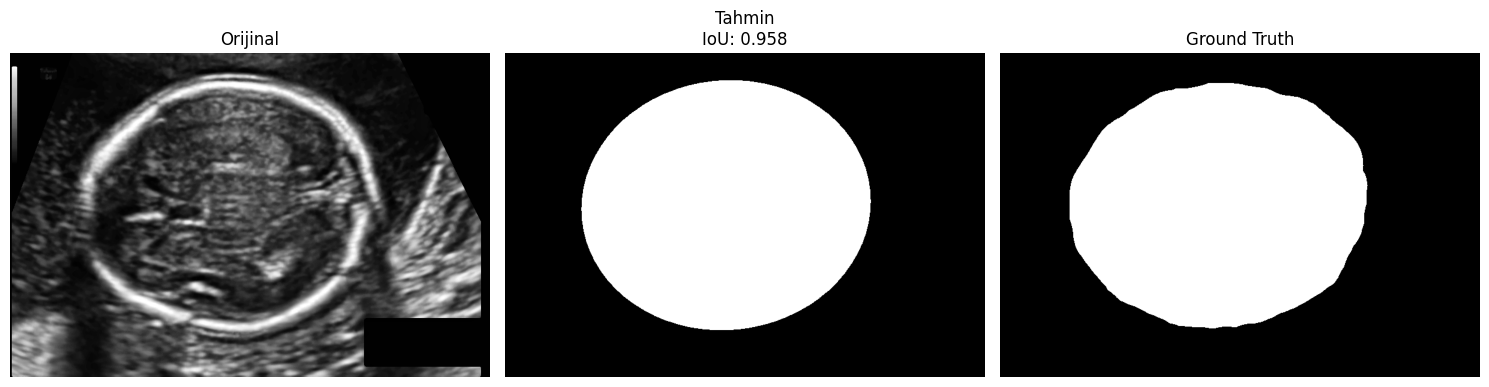

IoU: 0.958


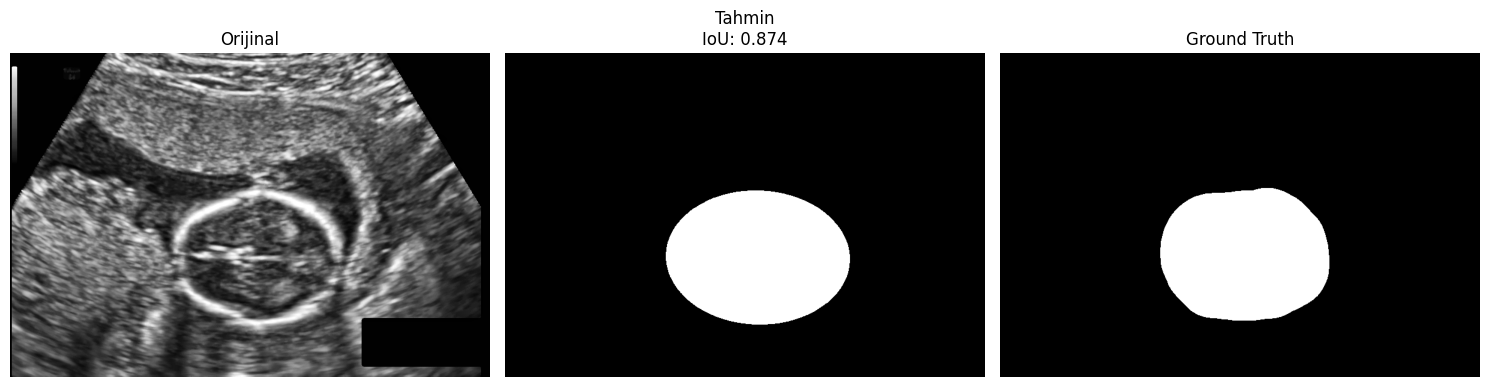

IoU: 0.874


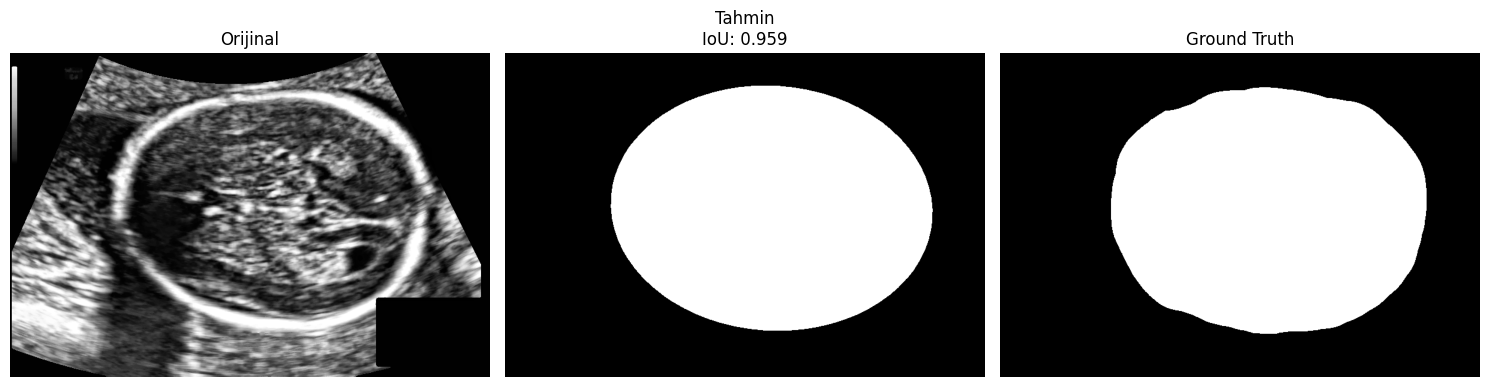

IoU: 0.959


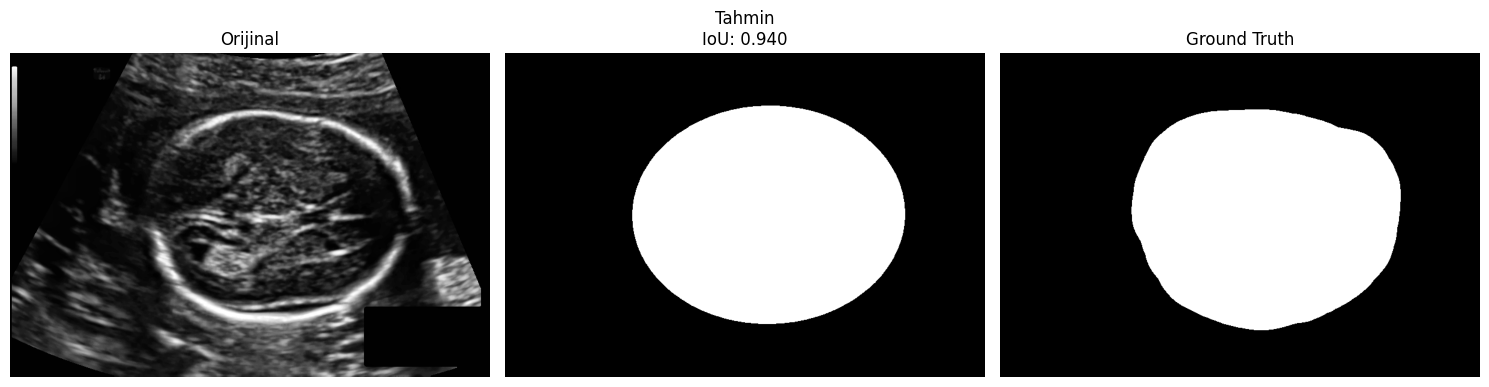

IoU: 0.940


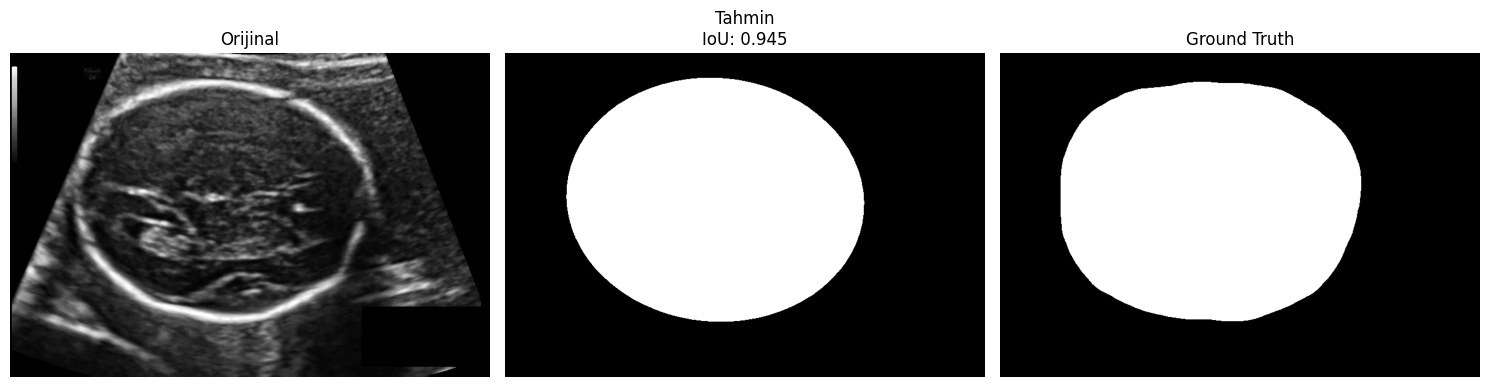

IoU: 0.945


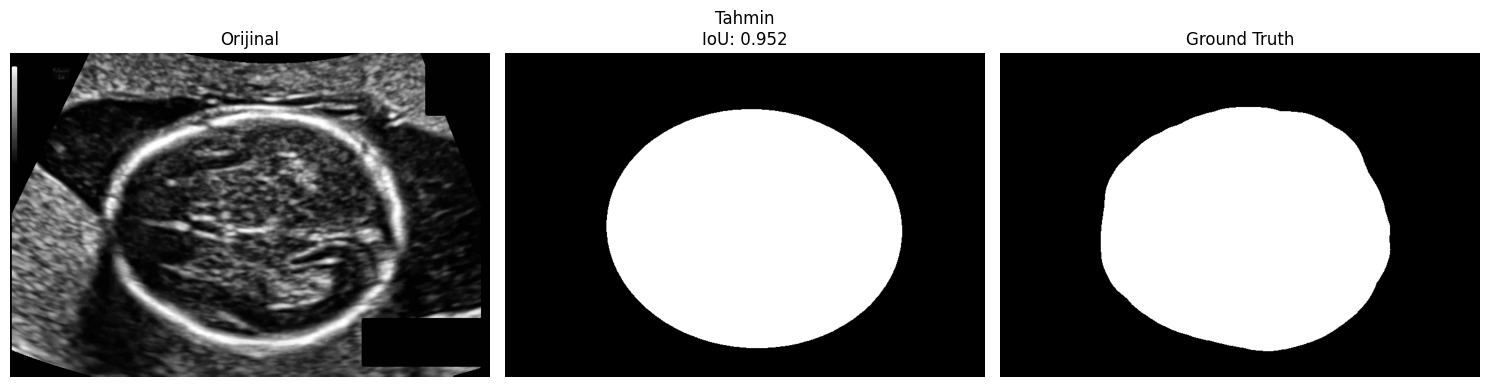

IoU: 0.952


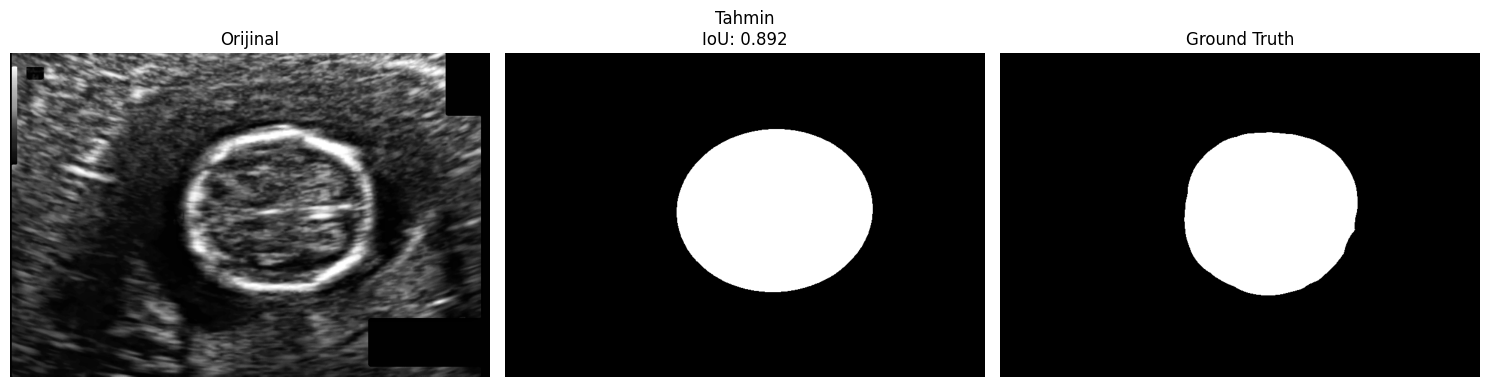

IoU: 0.892


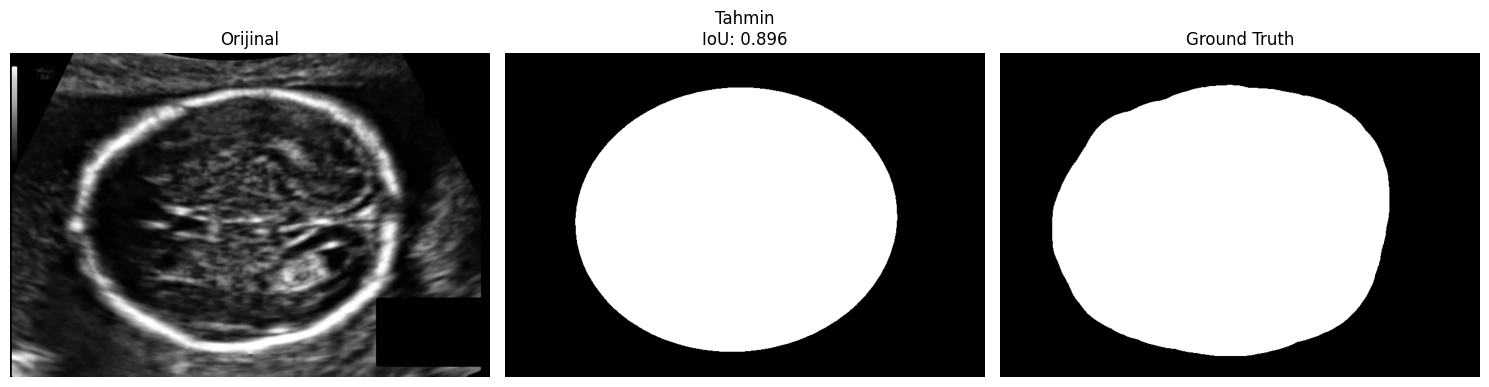

IoU: 0.896


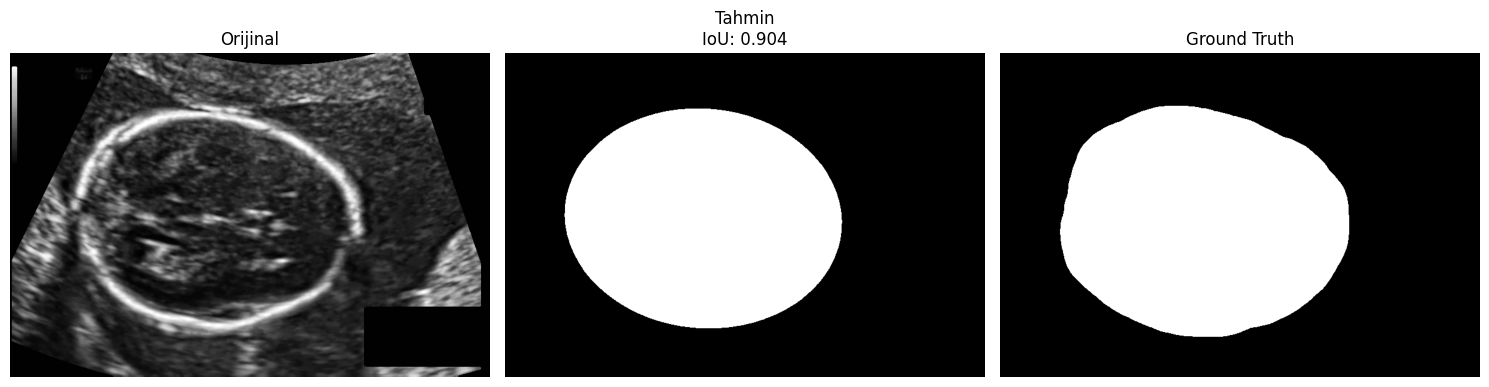

IoU: 0.904


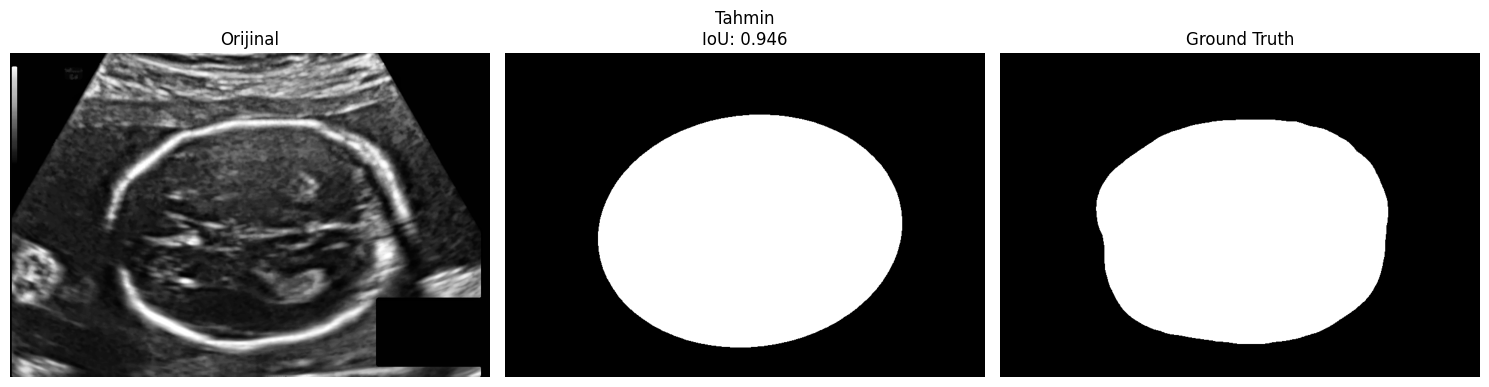

IoU: 0.946

Ortalama IoU: 0.927


In [51]:
# [Önceki tüm import'lar ve yardımcı fonksiyonlar aynı]

def find_similar_signals_with_ellipse(reference_signal, test_signals, line_info_list, image, points_for_ellipse, threshold=0.5):
    best_correlations = []
    similar_lines = []
    best_signal = None
    best_correlation = -np.inf
    best_index = -1
    
    reference_signal = np.array(reference_signal)
    reference_signal = (reference_signal - np.min(reference_signal)) / (np.max(reference_signal) - np.min(reference_signal))
    
    bright_lines = []
    for i, test_signal in enumerate(test_signals):
        if len(test_signal) >= 10:
            pixels_5_10 = test_signal[5:10]
            if all(pixel >= 230 for pixel in pixels_5_10):
                bright_lines.append(i)
    
    for i in bright_lines:
        test_signal = np.array(test_signals[i]) / 255.0
        
        best_corr = -np.inf
        best_scale = None
        best_scaled_signal = None
        
        for factor in np.linspace(0.4, 1.0, 5):
            scaled_test = np.interp(
                np.linspace(0, len(test_signal), int(len(test_signal) * factor)), 
                np.arange(len(test_signal)), 
                test_signal
            )
            
            scaled_ref = np.interp(
                np.linspace(0, len(reference_signal), len(scaled_test)), 
                np.arange(len(reference_signal)), 
                reference_signal
            )
            
            correlation = np.max(np.correlate(scaled_test, scaled_ref, mode='valid'))
            
            if correlation > best_corr:
                best_corr = correlation
                best_scale = factor
                best_scaled_signal = scaled_test
                best_scaled_ref = scaled_ref
        
        best_correlations.append(best_corr)
        
        if best_corr > best_correlation:
            best_correlation = best_corr
            best_signal = best_scaled_signal
            best_ref_signal = best_scaled_ref
            best_index = i
        
        if best_corr > threshold:
            similar_lines.append(line_info_list[i])
    
    ellipse_model = fit_ellipse_to_points(line_info_list, bright_lines)
    
    return similar_lines, best_correlations, ellipse_model

def process_single_image(image_path, label_path, referans_sinyal):
    """
    Tek bir görüntüyü işle ve sonuçları döndür
    """
    image = io.imread(image_path, as_gray=True)
    processed_image = preprocess_image(image)
    
    label_mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    if label_mask is None:
        raise FileNotFoundError(f"Label dosyası bulunamadı: {label_path}")
    
    _, label_mask = cv2.threshold(label_mask, 127, 255, cv2.THRESH_BINARY)
    
    edges = feature.canny(processed_image, sigma=5, low_threshold=0.1, high_threshold=0.3)
    lines_image, color_vectors, line_info_list, points_for_ellipse = draw_perpendicular_lines(
        edges, 
        processed_image, 
        line_length=50, 
        step=10
    )
    
    similar_lines, correlations, ellipse_model = find_similar_signals_with_ellipse(
        referans_sinyal,
        color_vectors,
        line_info_list,
        processed_image,
        points_for_ellipse,
        threshold=10
    )
    
    pred_mask = create_ellipse_mask(image.shape, ellipse_model)
    
    iou = calculate_iou(pred_mask > 0, label_mask > 0)
    
    return processed_image, pred_mask, label_mask, iou, ellipse_model

def main():
    try:
        with open('sinyaller.pkl', 'rb') as f:
            referans_sinyal = pickle.load(f)
        
        images_dir = r"../data/test_images"
        labels_dir = r"../data/test_labels"
        
        all_ious = []
        
        for img_name in os.listdir(images_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(images_dir, img_name)
                label_path = os.path.join(labels_dir, img_name)
                
                image, pred_mask, label_mask, iou, ellipse_model = process_single_image(
                    image_path, 
                    label_path, 
                    referans_sinyal
                )
                
                all_ious.append(iou)
                
                # Sonuçları görselleştir
                plt.figure(figsize=(15, 5))
                
                plt.subplot(131)
                plt.imshow(image, cmap='gray')
                plt.title('Orijinal')
                plt.axis('off')
                
                plt.subplot(132)
                plt.imshow(pred_mask, cmap='gray')
                plt.title(f'Tahmin\nIoU: {iou:.3f}')
                plt.axis('off')
                
                plt.subplot(133)
                plt.imshow(label_mask, cmap='gray')
                plt.title('Ground Truth')
                plt.axis('off')
                
                plt.tight_layout()
                plt.show()
                
                if ellipse_model is not None:
                    center, axes, angle = ellipse_model
                    print(f"IoU: {iou:.3f}")
        
        mean_iou = np.mean(all_ious)
        print(f"\nOrtalama IoU: {mean_iou:.3f}")
        
    except Exception as e:
        print(f"Hata: {e}")
    finally:
        plt.close('all')

if __name__ == "__main__":
    main()